# PCA Reconstruction EDA

Dedicated notebook for pooled GTEx ground-truth PCA recovery analyses on cache-backed strict LORO rows.




In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.results_eda import *

In [2]:
import importlib
import src.eval_utils.results_eda as results_eda
importlib.reload(results_eda)
from src.eval_utils.results_eda import *

In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope='allgenes',
    naive_cache_dirname='naive',
    dlam_cache_dirname='dlam',
    plam_cache_dirname='plam',
)
CFG
print('analysis scope:', CFG.gene_scope)



analysis scope: allgenes


## 1) Dataset Context

This notebook treats each subject-parcel row as a sample and each gene as a feature.
So the PCA fit matrix has shape:

$$
X_{\mathrm{true},h} \in \mathbb{R}^{n_{\mathrm{samples}} \times n_{\mathrm{genes}}}
$$

Here $n_{\mathrm{samples}}$ is the total number of strict held-out subject-parcel rows pooled across eligible subjects, not the number of subjects and not the full atlas size including AHBA.




In [4]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('eligible subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


eligible subjects: 318
genes: 13618
parcels: 150


## 2) Pooled Sample Matrices

We first pull two aligned pooled data frames from cache:
- `truth_df_*`: strict held-out truth rows
- `pred_df_*`: aligned model prediction rows on the same `(subject, parcel_idx)` keys


In [5]:
MODELS = ['naive', 'dlam', 'plam']
N_JOBS = 16
EVAL_GENE_PATH = None  # set to 'ahba_100hvg', 'gtex_100hvg', 'gtex_25deg', etc.

truth_df_naive, pred_df_naive = collect_pooled_sample_prediction_dfs_from_cache_gene_subset(
    CFG,
    model='naive',
    eval_gene_path=EVAL_GENE_PATH,
    n_jobs=N_JOBS,
)
truth_df_dlam, pred_df_dlam = collect_pooled_sample_prediction_dfs_from_cache_gene_subset(
    CFG,
    model='dlam',
    eval_gene_path=EVAL_GENE_PATH,
    n_jobs=N_JOBS,
)
truth_df_plam, pred_df_plam = collect_pooled_sample_prediction_dfs_from_cache_gene_subset(
    CFG,
    model='plam',
    eval_gene_path=EVAL_GENE_PATH,
    n_jobs=N_JOBS,
)

display(truth_df_naive.head())
display(pred_df_naive.head())
print('naive shapes:', truth_df_naive.shape, pred_df_naive.shape)
print('sample keys aligned:', (truth_df_naive['sample_key'] == pred_df_naive['sample_key']).all())



,subject,parcel_idx,sample_key,sample_idx_subject,model,eval_gene_mode,eval_gene_path,mixed_space_mode,DPM1,SCYL3,...,MRM1,HIST1H4A,GOLGA6L10,HIST1H2AM,HIST1H4B,HIST1H3H,MRPL45,PCDH20,PAGR1,TMEM265
0,GTEX-1117F,5,GTEX-1117F|5,0,naive,all,None,None,5.237353,3.014178,...,2.943969,1.561887,3.505472,4.470888,4.863447,2.127437,5.699000,1.250517,6.218362,3.250597
1,GTEX-1117F,10,GTEX-1117F|10,1,naive,all,None,None,5.246482,3.045238,...,3.217235,1.506255,3.542502,4.555119,4.862676,1.319629,5.581843,3.912728,6.362165,3.091069
2,GTEX-1117F,18,GTEX-1117F|18,2,naive,all,None,None,5.184985,3.045365,...,3.291385,1.506969,3.492359,4.798620,4.864834,1.686910,5.499541,4.284439,6.362572,3.103423
3,GTEX-1117F,19,GTEX-1117F|19,3,naive,all,None,None,5.299481,3.069595,...,3.244307,1.506277,3.575236,4.810700,4.862178,1.487257,5.653855,3.580846,6.368560,3.076855
4,GTEX-1117F,29,GTEX-1117F|29,4,naive,all,None,None,5.407557,3.060759,...,2.908304,1.506248,3.545862,4.516249,4.863857,2.449167,5.933543,2.875592,6.387455,3.082352


,subject,parcel_idx,sample_key,sample_idx_subject,model,eval_gene_mode,eval_gene_path,mixed_space_mode,DPM1,SCYL3,...,MRM1,HIST1H4A,GOLGA6L10,HIST1H2AM,HIST1H4B,HIST1H3H,MRPL45,PCDH20,PAGR1,TMEM265
0,GTEX-1117F,5,GTEX-1117F|5,0,naive,all,None,None,5.160922,2.381735,...,3.165953,1.541428,3.673922,5.244865,5.976554,2.313064,5.854665,0.984247,6.954978,3.086737
1,GTEX-1117F,10,GTEX-1117F|10,1,naive,all,None,None,5.847799,3.151138,...,3.765726,0.781725,4.536182,5.834588,6.065064,2.181073,6.716814,3.883568,8.021265,3.469866
2,GTEX-1117F,18,GTEX-1117F|18,2,naive,all,None,None,5.777831,3.140528,...,2.402404,2.859330,4.503953,6.386307,7.091222,3.478383,6.251956,4.185190,7.502801,3.259064
3,GTEX-1117F,19,GTEX-1117F|19,3,naive,all,None,None,5.911385,3.194874,...,3.351465,1.028587,4.582115,6.167117,6.120930,2.024480,6.840936,3.495154,7.928071,3.370401
4,GTEX-1117F,29,GTEX-1117F|29,4,naive,all,None,None,5.314977,3.032518,...,2.632245,1.136881,4.177752,6.433882,6.511618,2.640820,6.304029,3.872395,7.393399,2.938594


naive shapes: (2820, 13626) (2820, 13626)
sample keys aligned: True


In [6]:
meta_cols = ['subject', 'parcel_idx', 'sample_key', 'sample_idx_subject', 'model', 'eval_gene_mode', 'eval_gene_path', 'mixed_space_mode']
gene_cols = [c for c in truth_df_naive.columns if c not in meta_cols]

X_true_h = truth_df_naive[gene_cols].to_numpy(dtype=np.float64)
X_pred_naive_h = pred_df_naive[gene_cols].to_numpy(dtype=np.float64)
X_pred_dlam_h = pred_df_dlam[gene_cols].to_numpy(dtype=np.float64)
X_pred_plam_h = pred_df_plam[gene_cols].to_numpy(dtype=np.float64)

print('X_true_h:', X_true_h.shape)
print('X_pred_naive_h:', X_pred_naive_h.shape)
print('X_pred_dlam_h:', X_pred_dlam_h.shape)
print('X_pred_plam_h:', X_pred_plam_h.shape)

# inspect why we only have 2820 samples instead of the full 3030

X_true_h: (2820, 13618)
X_pred_naive_h: (2820, 13618)
X_pred_dlam_h: (2820, 13618)
X_pred_plam_h: (2820, 13618)


## 3) Standard Pooled PCA

This is the default pooled PCA analysis.

What happens mathematically:
- fit PCA on `X_true_h`
- sklearn PCA centers each gene globally across all pooled samples
- project each model prediction matrix into that same truth PCA basis
- compare true vs predicted PC scores component-wise across the pooled sample axis

Why the naive model can look nontrivial here:
- pooled PCA still contains parcel fixed effects
- naive fill reproduces parcel template structure reasonably well
- so it can score well on parcel-driven PCs even if it misses subject-specific variation




In [7]:
pc_df, pc_summary = compute_pooled_pca_recovery_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='none',
    n_jobs=N_JOBS,
)

spectra_df, spectra_summary = compute_pooled_pca_variance_spectra_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='none',
    n_jobs=N_JOBS,
)

display(pc_summary)
display(spectra_summary)



,model,mean_score_pearson,var_weighted_score_pearson,pc1_score_pearson,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,naive,0.024377,0.375030,0.150669,213,2820,13618,300,all,None,none,None
1,dlam,0.367923,0.312831,0.168591,213,2820,13618,300,all,None,none,None
2,plam,0.235848,0.354461,0.155212,213,2820,13618,300,all,None,none,None


,source,pc1_explained_variance_ratio,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,truth,0.283535,213,2820,13618,300,all,None,none,None
1,naive,0.424601,7,2820,13618,300,all,None,none,None
2,dlam,0.831589,8,2820,13618,300,all,None,none,None
3,plam,0.583388,9,2820,13618,300,all,None,none,None


In [8]:
spectra_df

,source,component,explained_variance_ratio,cumulative_variance,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,truth,1,0.283535,0.283535,213,2820,13618,300,all,None,none,None
1,truth,2,0.158005,0.441540,213,2820,13618,300,all,None,none,None
2,truth,3,0.098467,0.540007,213,2820,13618,300,all,None,none,None
3,truth,4,0.069582,0.609589,213,2820,13618,300,all,None,none,None
4,truth,5,0.052536,0.662125,213,2820,13618,300,all,None,none,None
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,plam,296,0.000013,0.998500,9,2820,13618,300,all,None,none,None
1196,plam,297,0.000012,0.998513,9,2820,13618,300,all,None,none,None
1197,plam,298,0.000012,0.998525,9,2820,13618,300,all,None,none,None
1198,plam,299,0.000012,0.998537,9,2820,13618,300,all,None,none,None


### Standard PCA Variance Spectrum By Source

Each source gets its own PCA variance-spectrum plot.

Why this comes first:
- it shows the intrinsic variance geometry of the truth matrix and of each model matrix separately
- the 95% threshold is source-specific here, so each panel answers: how many PCs does *this* source need to explain most of its own variance?




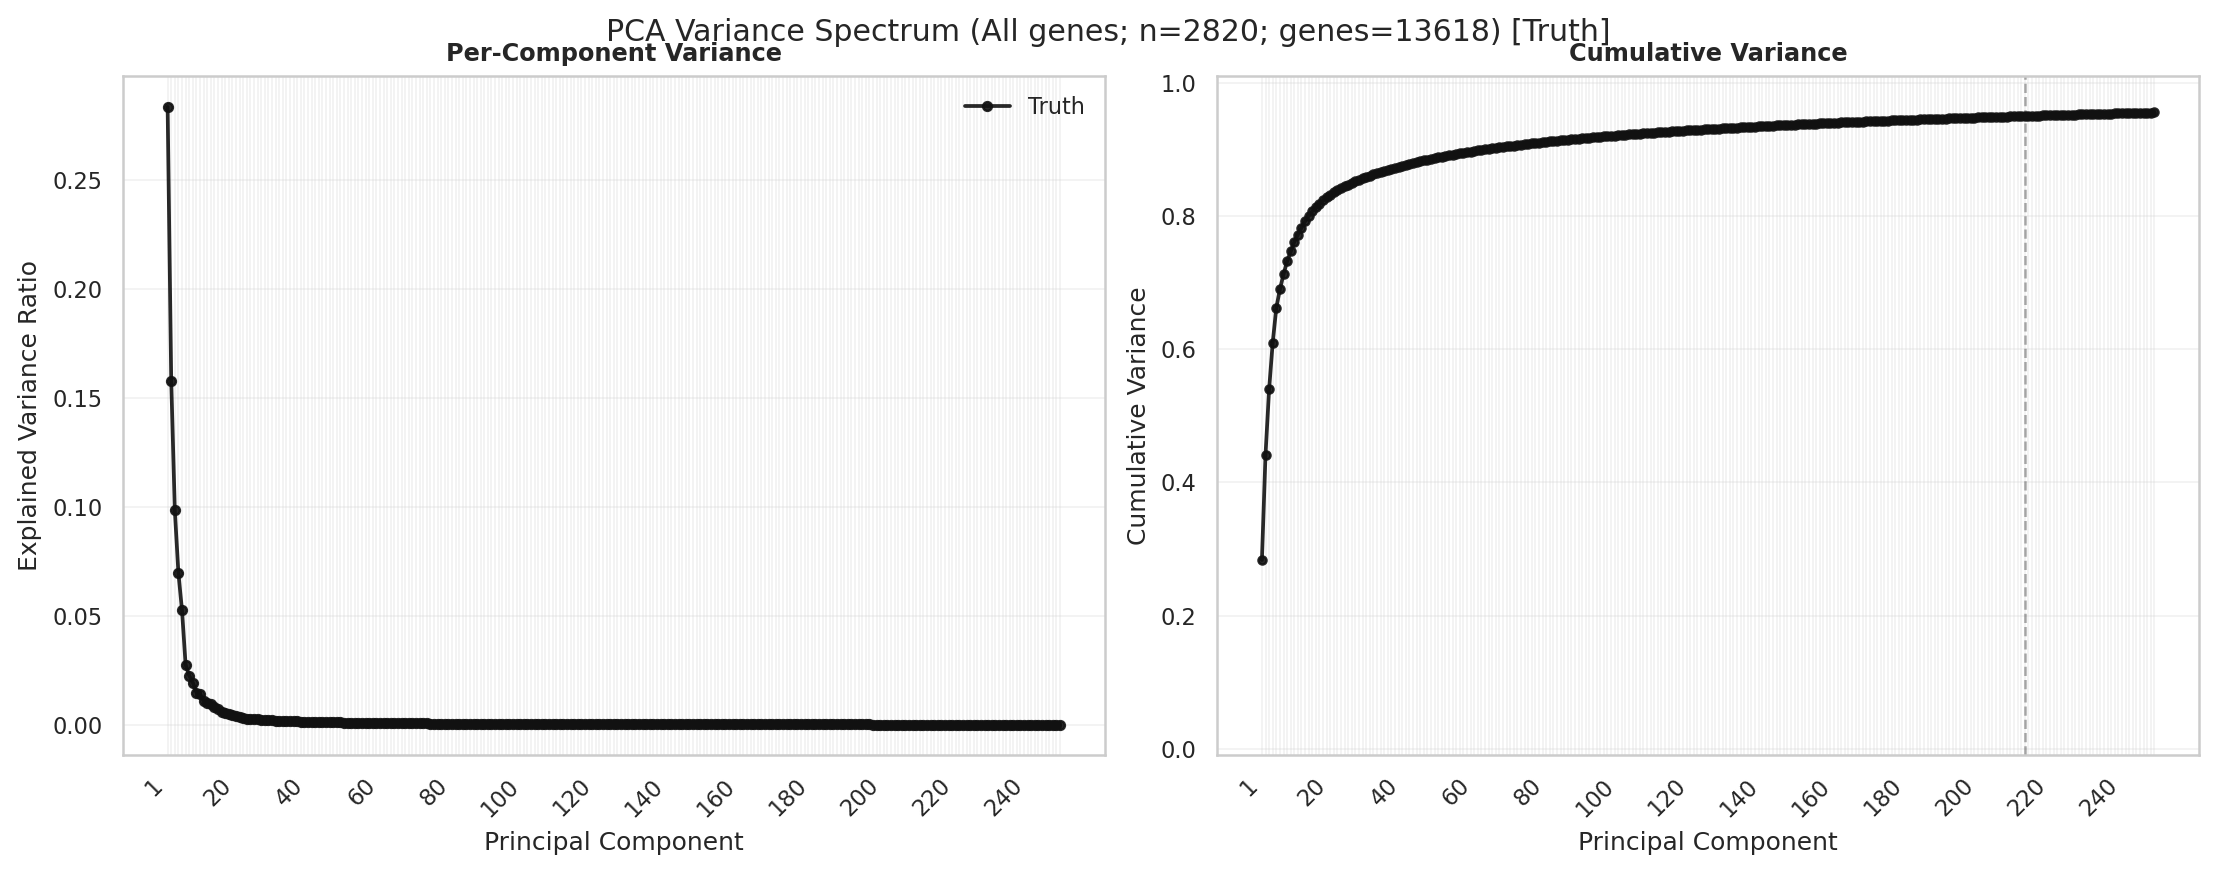

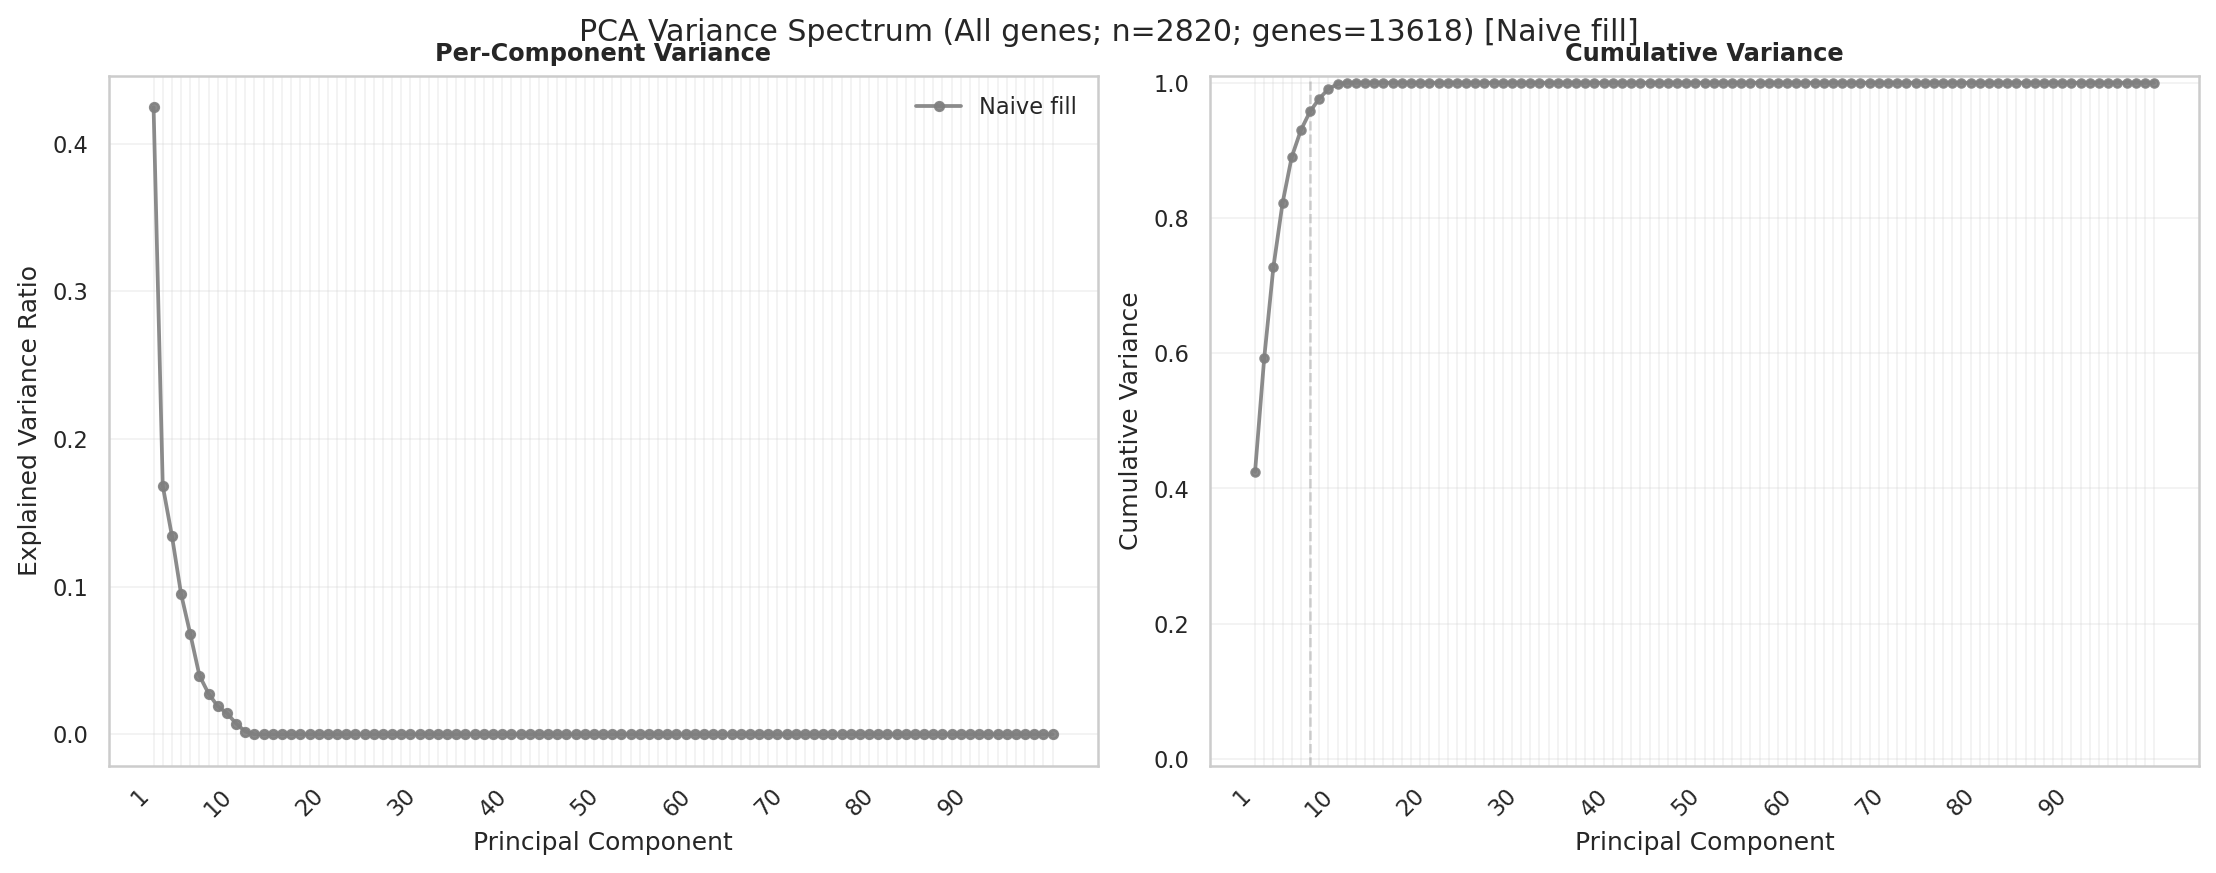

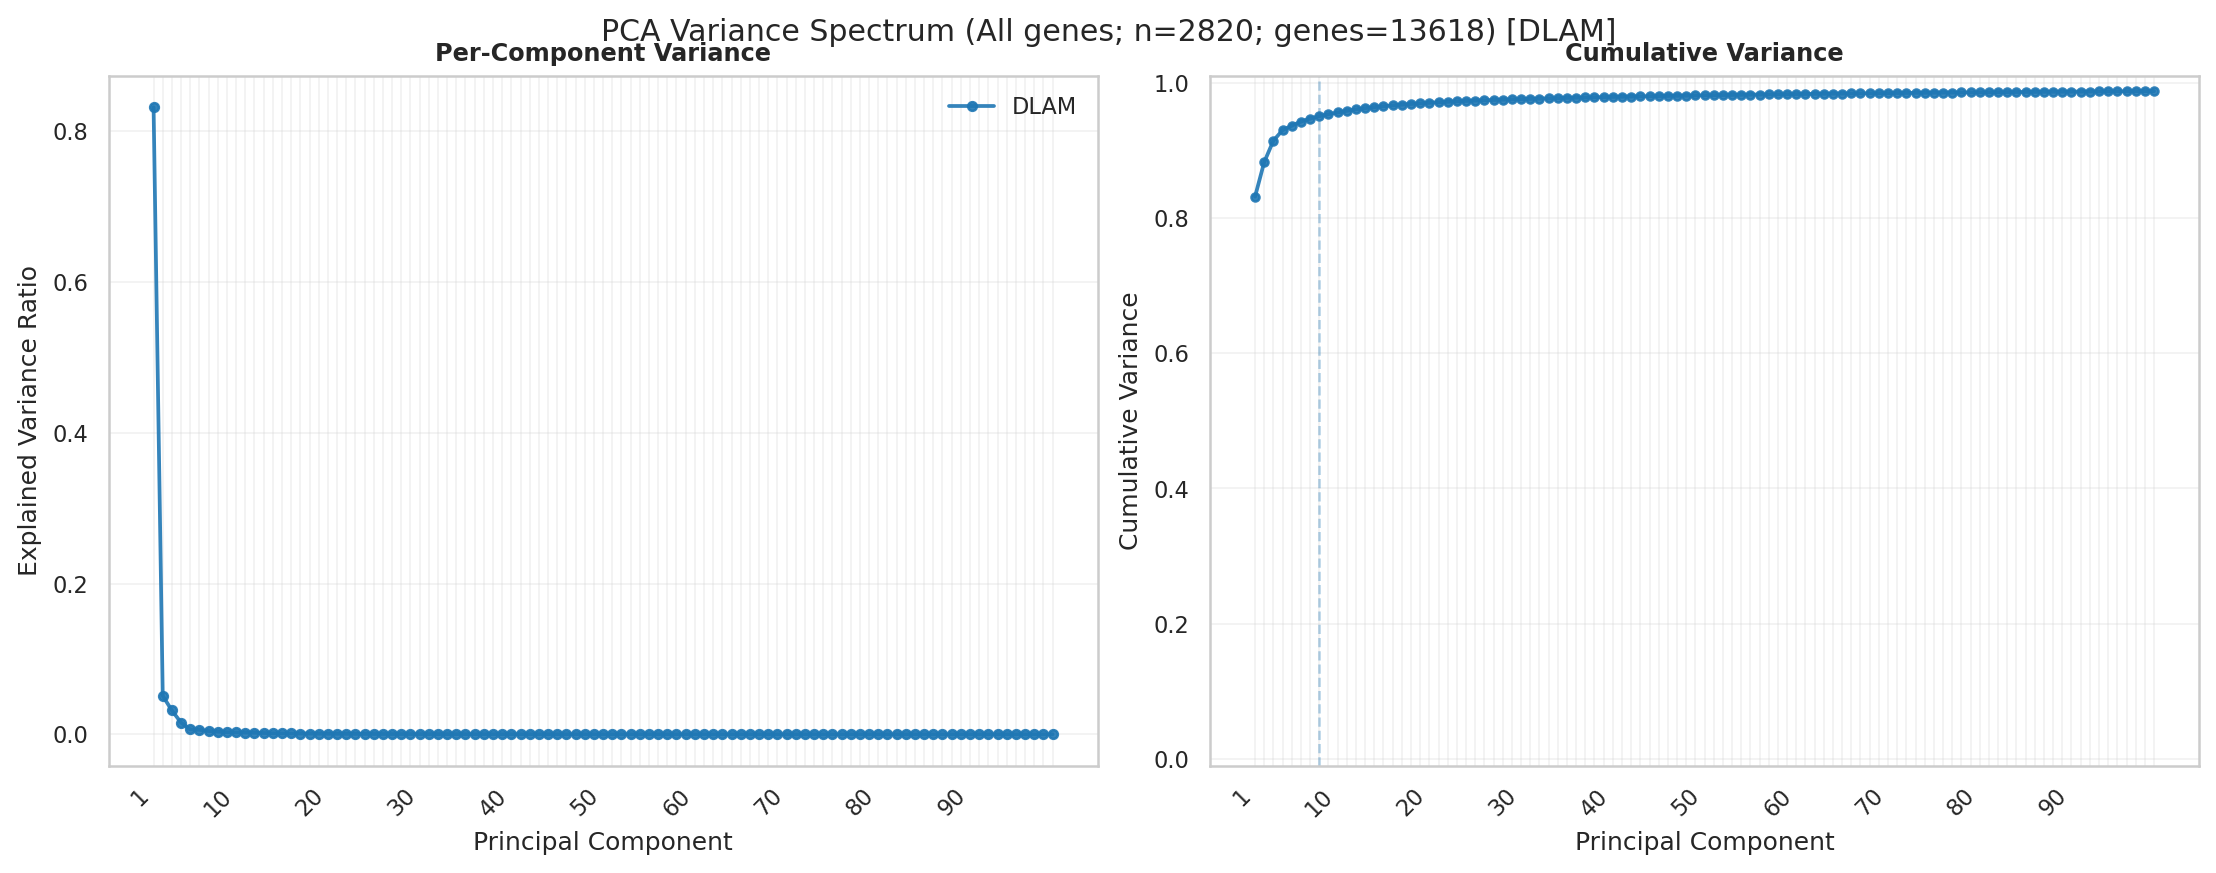

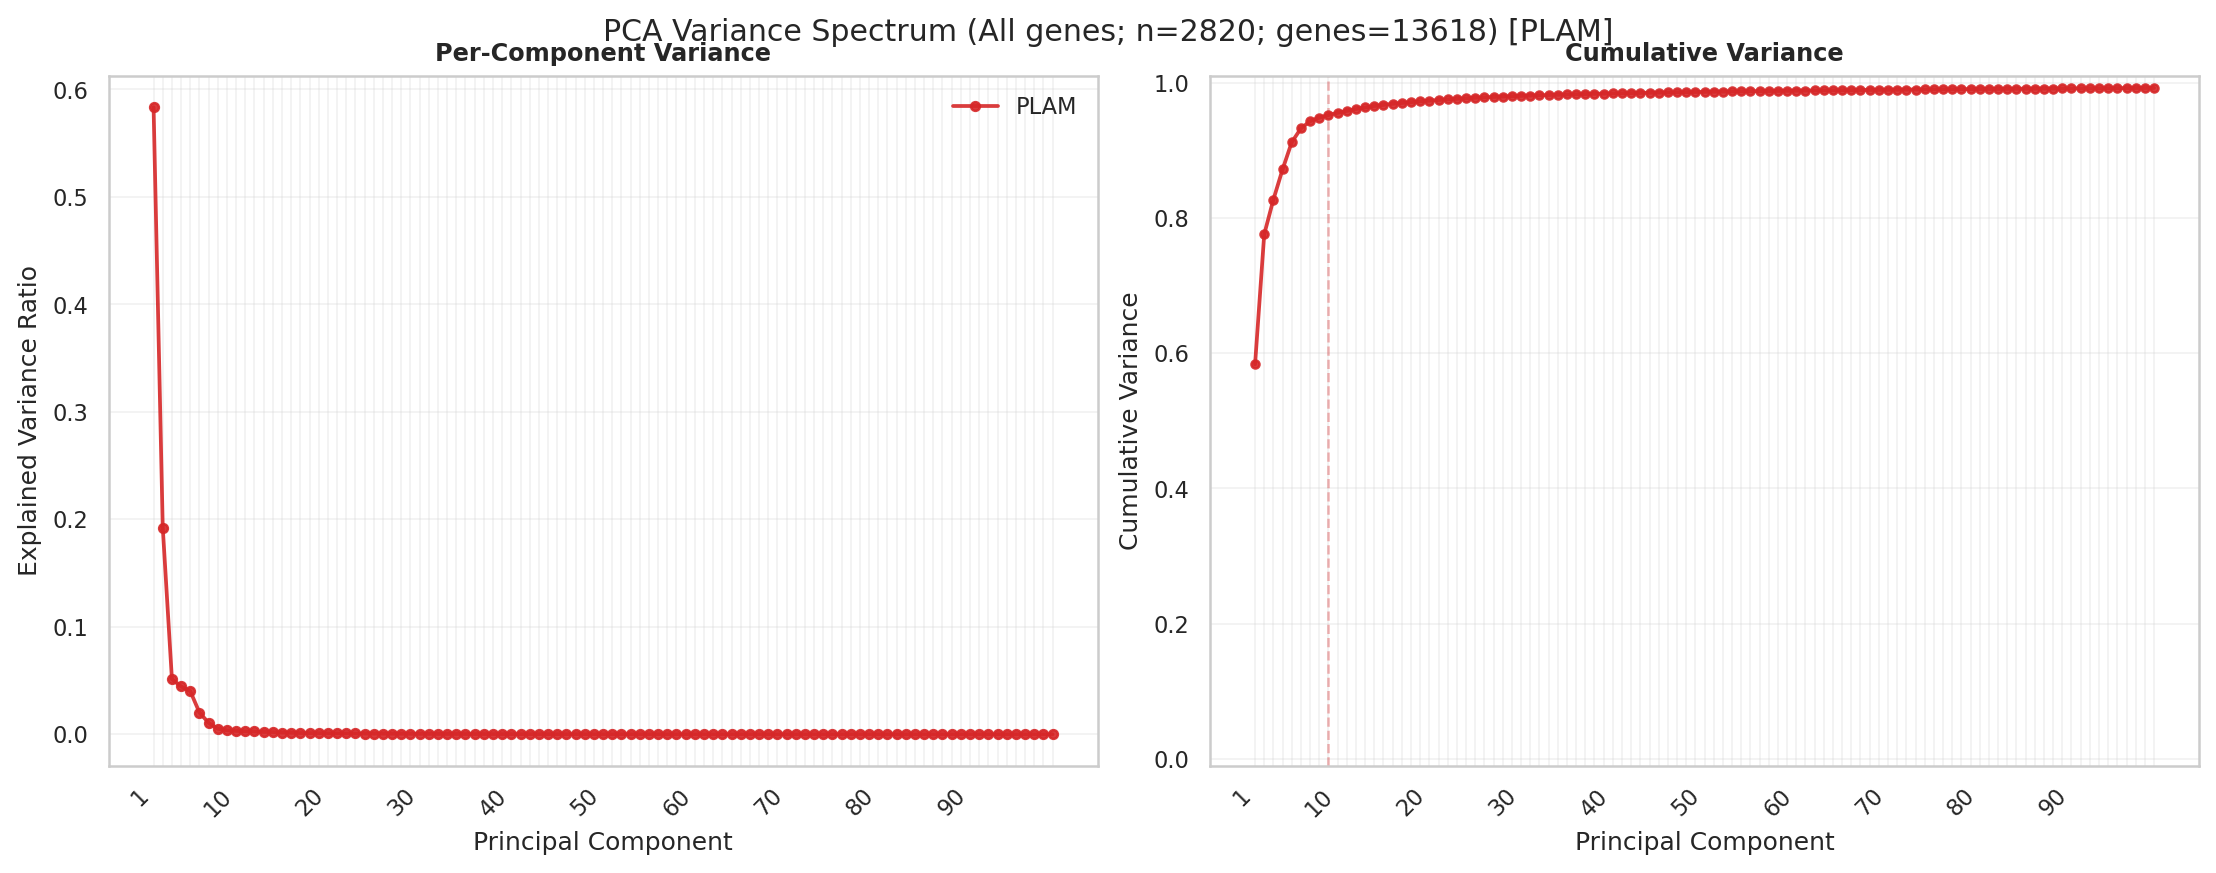

In [9]:
# Plot for 'truth' with 250 PCs and x_label_stride=20
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'truth') & (spectra_df['component'] < 250)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=20,
    source='truth',
)

# Plot for 'naive' with 100 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'naive') & (spectra_df['component'] < 100)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=10,
    source='naive',
)

# Plot for 'dlam' with 100 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'dlam') & (spectra_df['component'] < 100)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=10,
    source='dlam',
)

# Plot for 'plam' with 100 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'plam') & (spectra_df['component'] < 100)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=10,
    source='plam',
)



### Standard PCA Recovery: Raw Points and LOWESS Trend

This plot asks a different question than the variance spectrum.

Here the PCA basis is always defined by truth, and we ask for each component $j$ how well the predicted scores align with the true scores across pooled samples:
- compare $C_{\mathrm{true}}[:, j]$ to $C_{\mathrm{pred}}[:, j]$

So this is a component-wise recovery plot, not a model-specific variance-spectrum plot.

In the first panel we show the raw per-component points only.
In the second panel we overlay a LOWESS smooth to summarize the overall recovery profile without forcing a parametric decay shape.
The dashed vertical line marks the 95% variance-explained cutoff in the true data, and the truth points are computed directly from the component-wise truth-vs-truth scores.




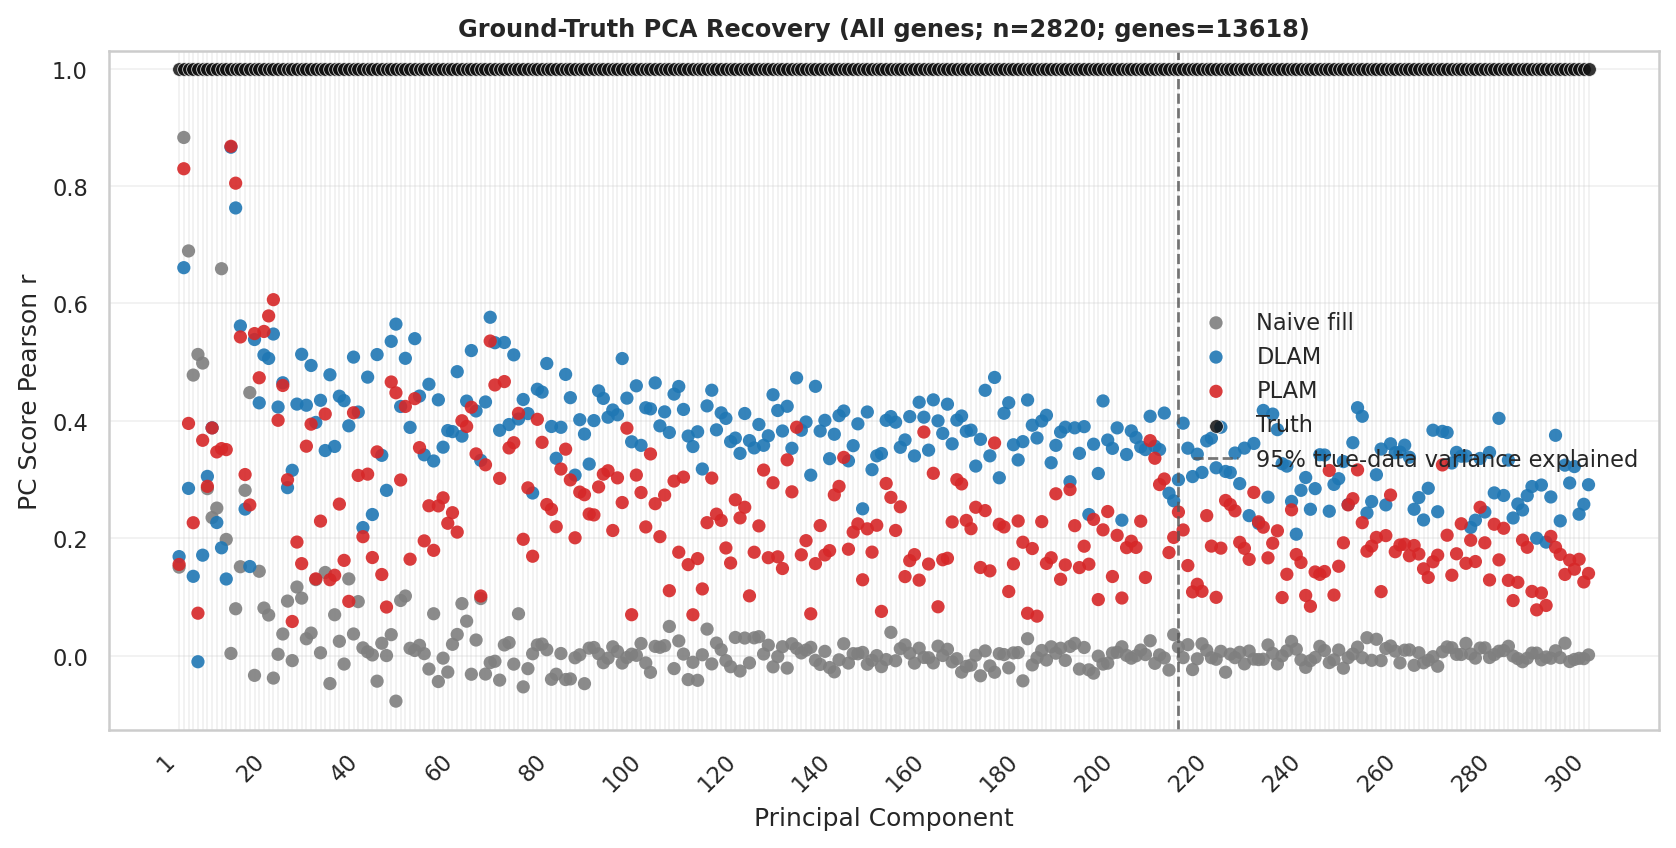

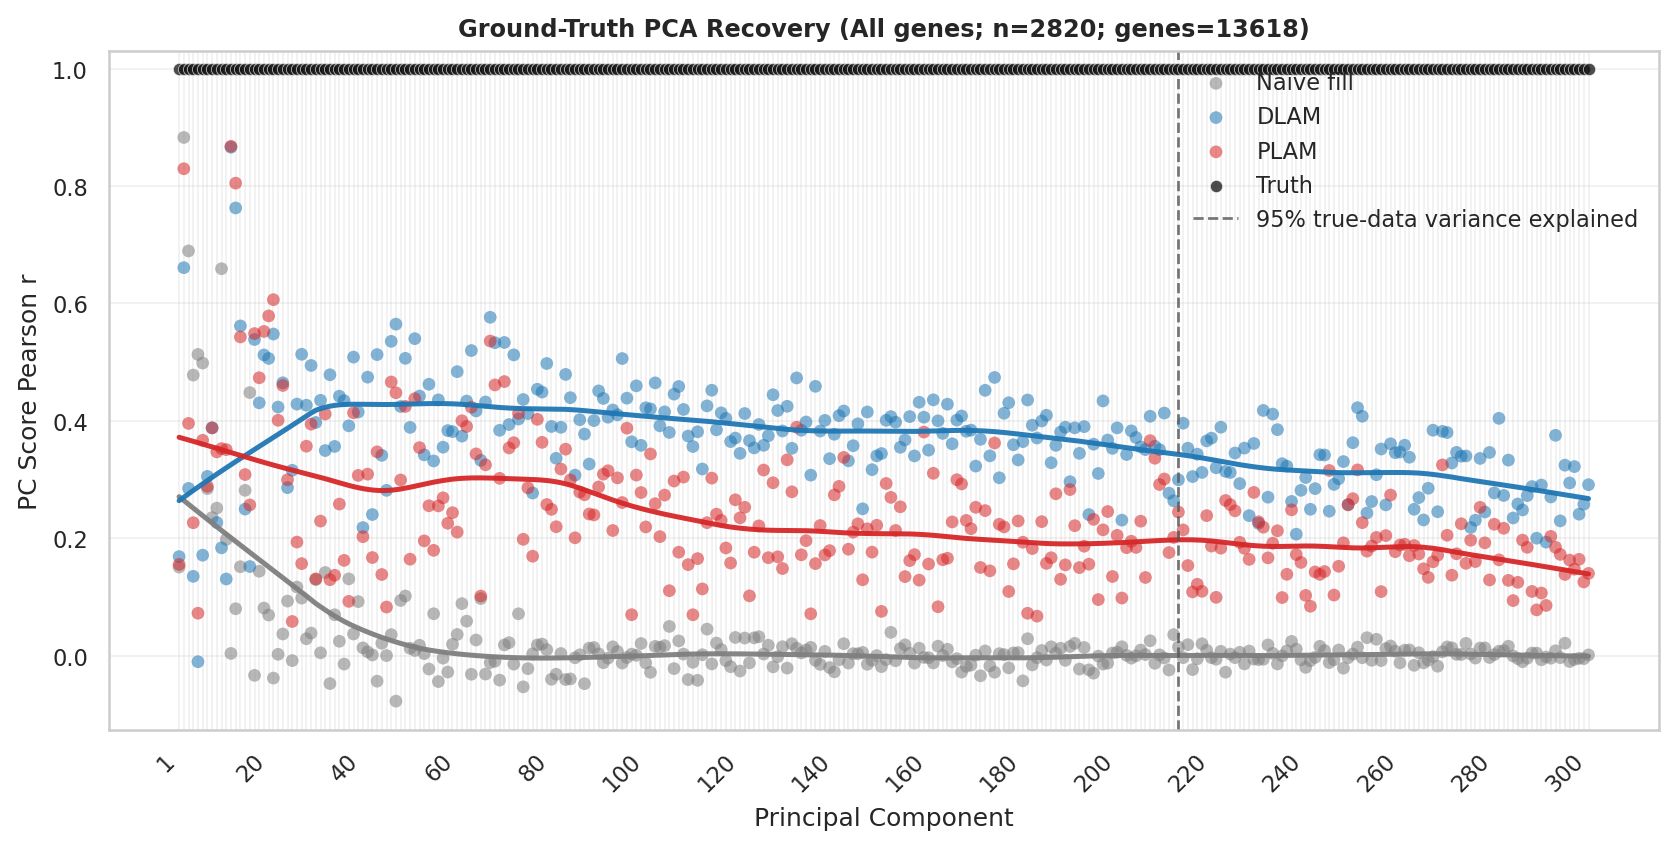

In [10]:
fig, ax, pc_plot_df = plot_pooled_pca_recovery(
    pc_df,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_lines=False,
    show_truth=True,
    x_label_stride=20,
)

fig, ax, pc_plot_df_fit = plot_pooled_pca_recovery(
    pc_df,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_fit='lowess',
    lowess_frac=0.2,
    show_truth=True,
    x_label_stride=20,
)




## 4) Within-Parcel Demeaned Pooled PCA

This version explicitly removes parcel mean structure before PCA.

Mathematically, if sample $i$ belongs to parcel $p(i)$ and gene $g$ has value $x_{ig}$, define the truth parcel mean by

$$
\bar{x}_{pg} = \frac{1}{n_p} \sum_{i : p(i)=p} x_{ig}
$$

where $n_p$ is the number of pooled samples assigned to parcel $p$.

Then subtract that parcel mean within parcel:

$$
r_{ig} = x_{ig} - \bar{x}_{p(i)g}
$$

PCA is then fit on the residual matrix $R = [r_{ig}]$, after the usual global gene-wise centering performed by PCA itself.

Why this is useful:
- **the first step projects out the parcel fixed effect** (by parcel)
- the second step recenters the residual feature space for PCA (by gene)
- what remains is much more focused on subject-specific variation within parcel

Expected consequence for naive:
- naive fill mostly captures parcel-wise template effects
- once parcel means are removed, its residual structure should collapse toward zero

Expected consequence for DLAM/PLAM:
- if they reconstruct subject-varying residuals within parcel, they should remain above zero in this residualized PCA space



In [11]:
pc_df_dm, pc_summary_dm = compute_pooled_pca_recovery_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='within_parcel',
    n_jobs=N_JOBS,
)

spectra_df_dm, spectra_summary_dm = compute_pooled_pca_variance_spectra_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='within_parcel',
    n_jobs=N_JOBS,
)

display(pc_summary_dm)
display(spectra_summary_dm)



,model,mean_score_pearson,var_weighted_score_pearson,pc1_score_pearson,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,naive,-0.000089,-0.000078,-0.000011,300,2820,13618,300,all,None,within_parcel,None
1,dlam,0.317912,0.229477,0.152228,300,2820,13618,300,all,None,within_parcel,None
2,plam,0.197470,0.226160,0.163759,300,2820,13618,300,all,None,within_parcel,None


,source,pc1_explained_variance_ratio,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,truth,0.383996,300,2820,13618,300,all,None,within_parcel,None
1,naive,0.349920,8,2820,13618,300,all,None,within_parcel,None
2,dlam,0.819622,10,2820,13618,300,all,None,within_parcel,None
3,plam,0.592247,13,2820,13618,300,all,None,within_parcel,None


### Within-Parcel Demeaned Variance Spectrum By Source

These source-specific spectra now reflect residual variance after parcel means are removed.

Why the expected result changes:
- naive can look structured in the standard spectrum because it captures parcel fixed effects
- after parcel demeaning, the spectrum focuses on subject-specific residual variation within parcel
- this is where learned models should differ most clearly from naive if they reconstruct subject-level variance




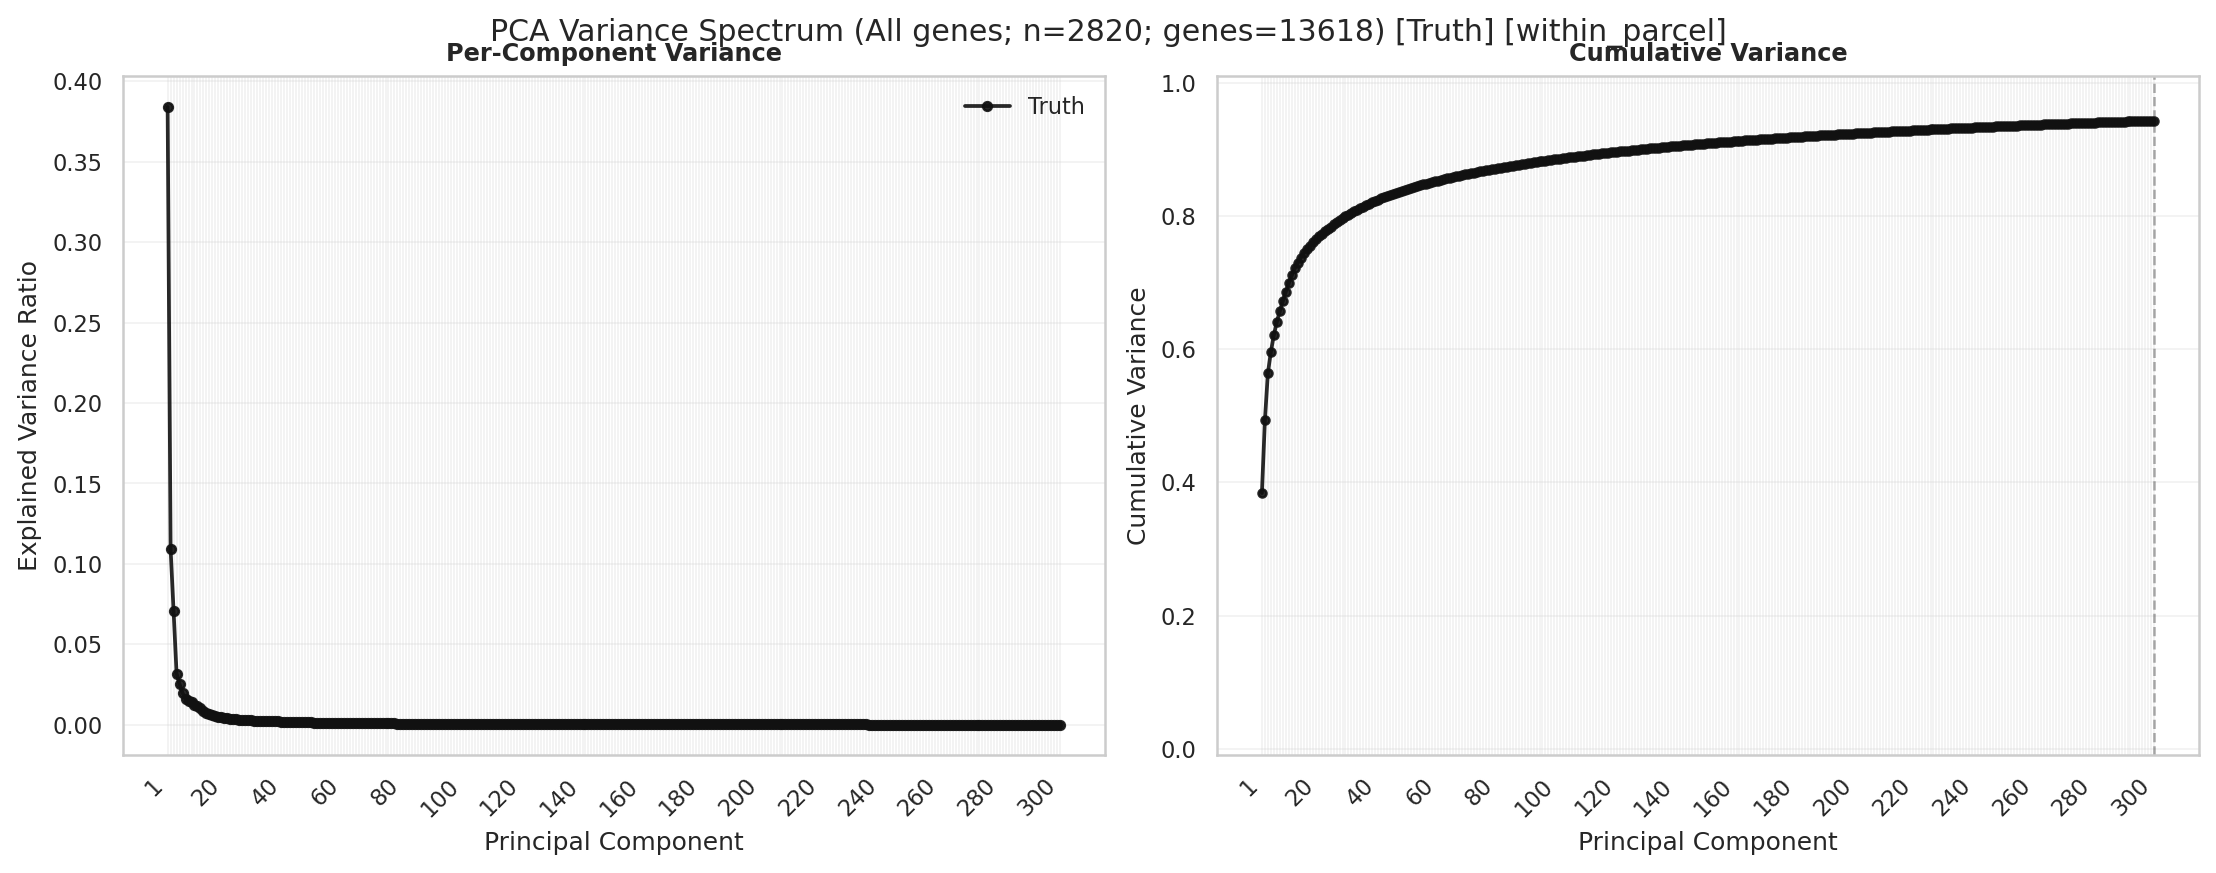

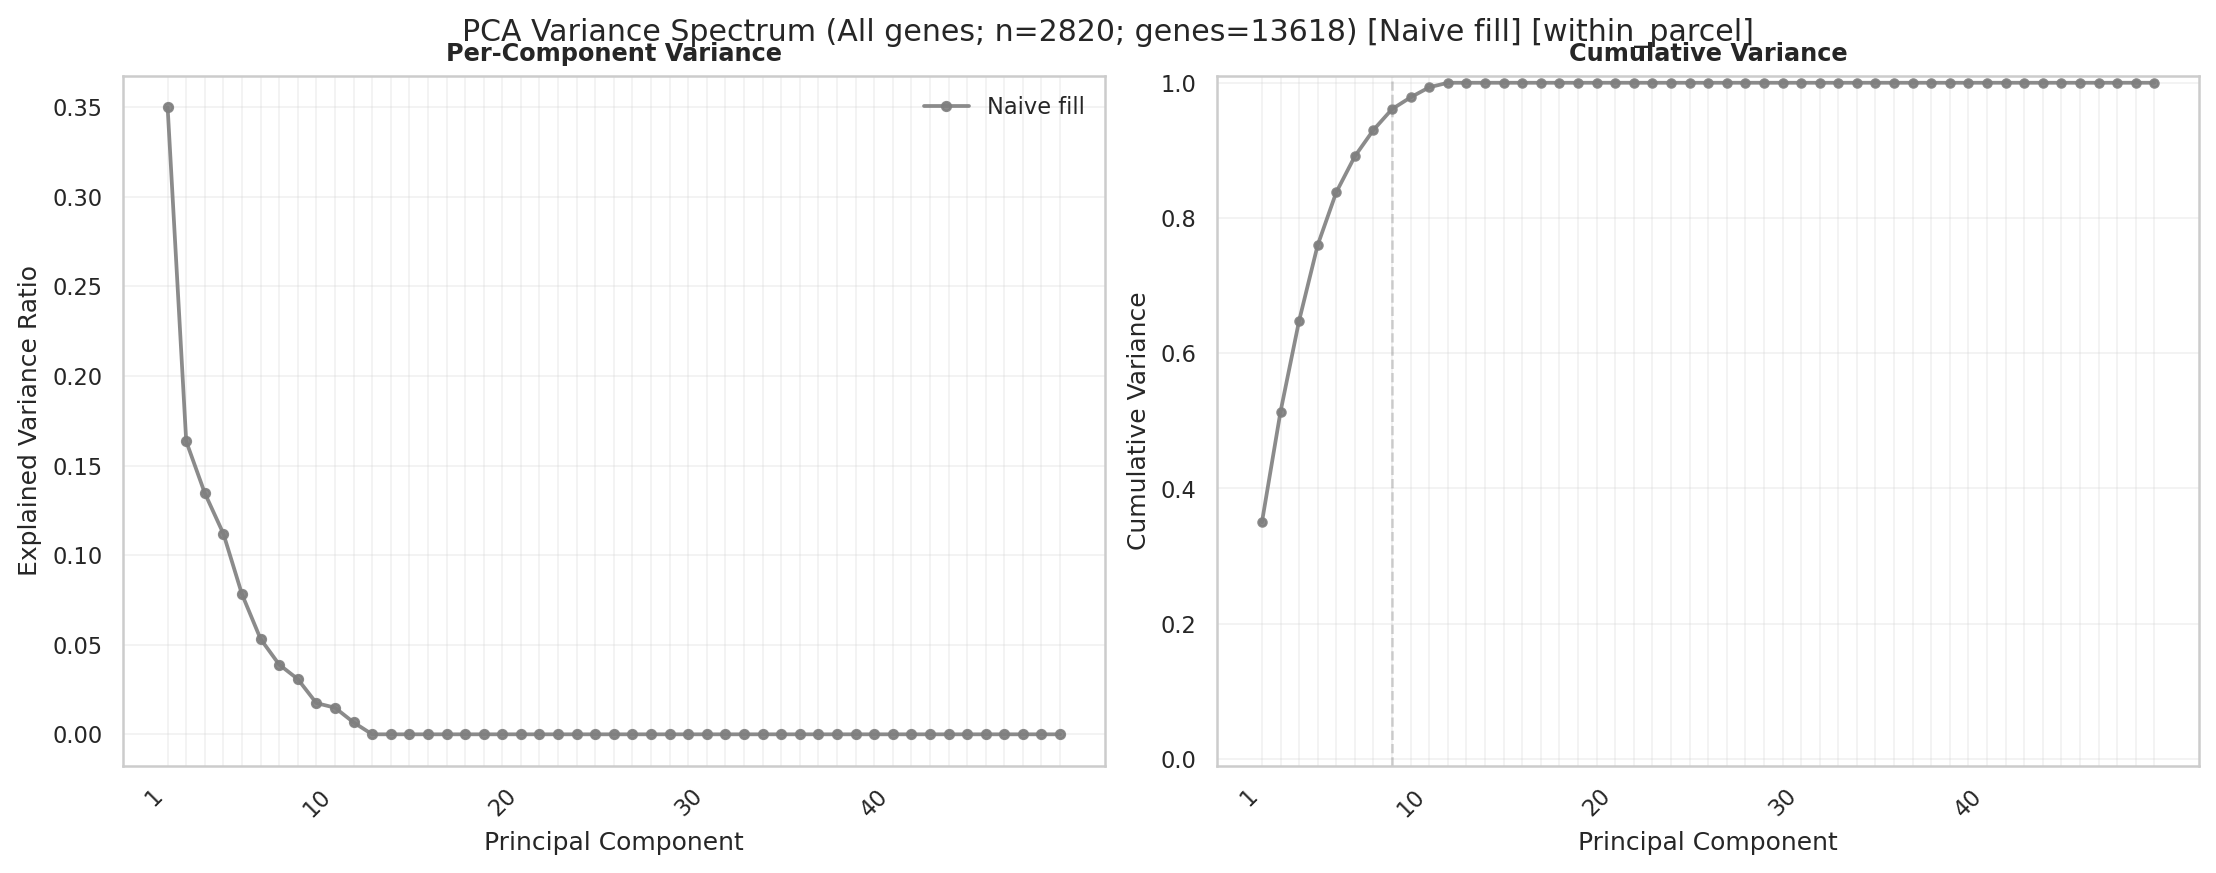

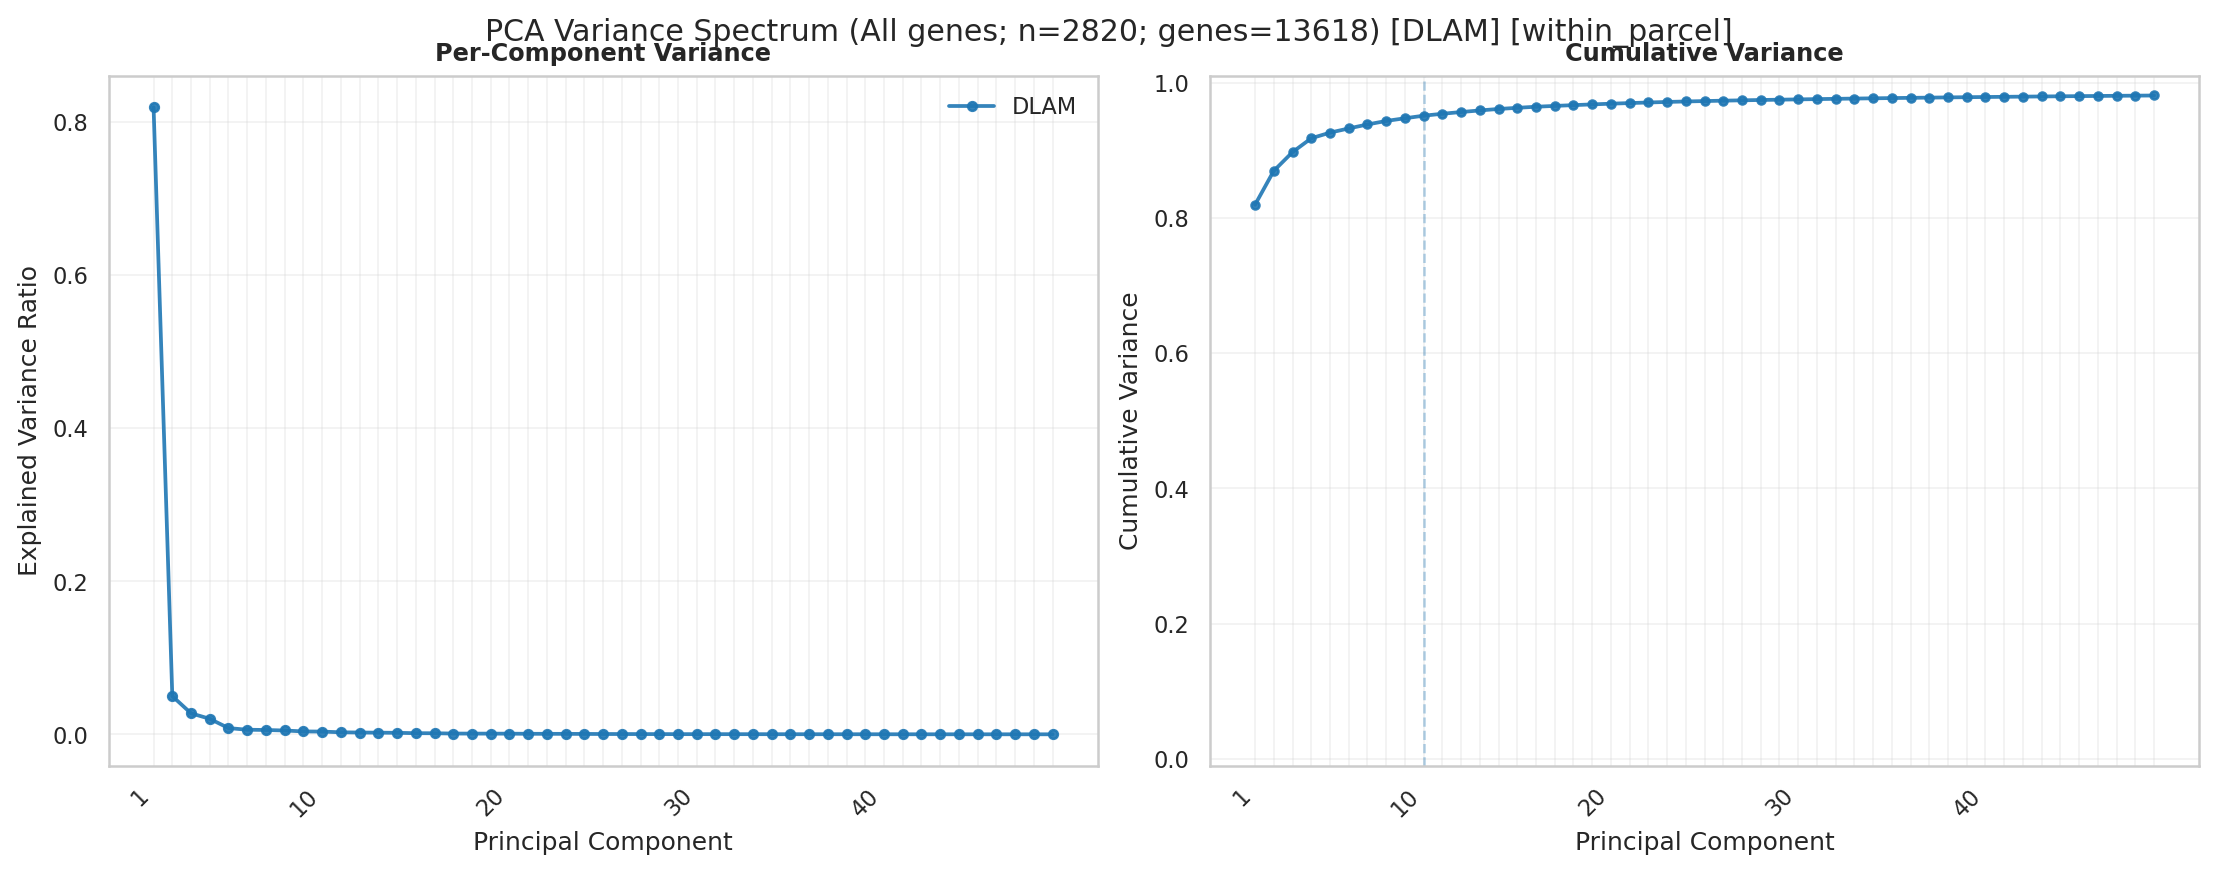

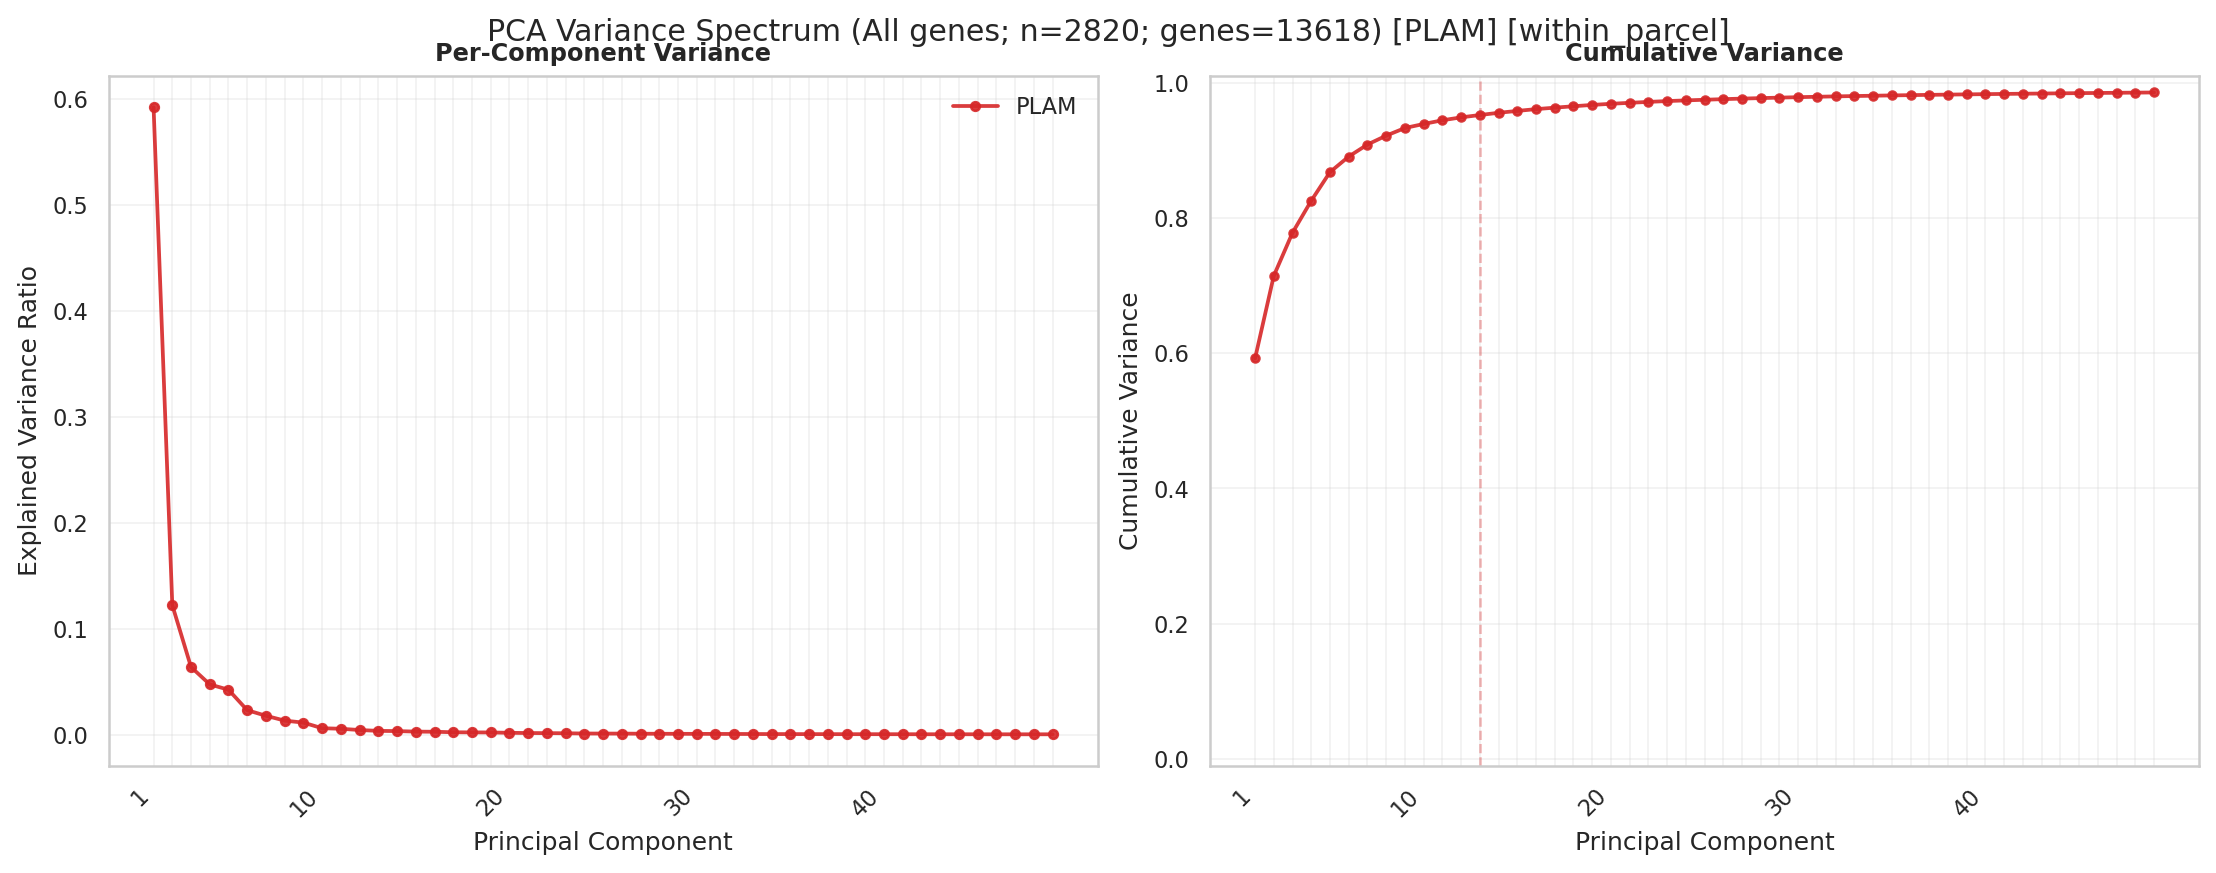

In [12]:
# Plot for 'truth' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'truth') & (spectra_df_dm['component'] < 350)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=20,
    source='truth',
)

# Plot for 'naive' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'naive') & (spectra_df_dm['component'] < 50)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=10,
    source='naive',
)

# Plot for 'dlam' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'dlam') & (spectra_df_dm['component'] < 50)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=10,
    source='dlam',
)

# Plot for 'plam' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'plam') & (spectra_df_dm['component'] < 50)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
        x_label_stride=10,
    source='plam',
)



### Within-Parcel PCA Recovery: Raw Points

Now the recovery plot is testing alignment in the parcel-demeaned residual space, which is much closer to a subject-specific variance question than the standard pooled PCA.

The first plot shows the raw per-component recovery points plus the computed truth reference.




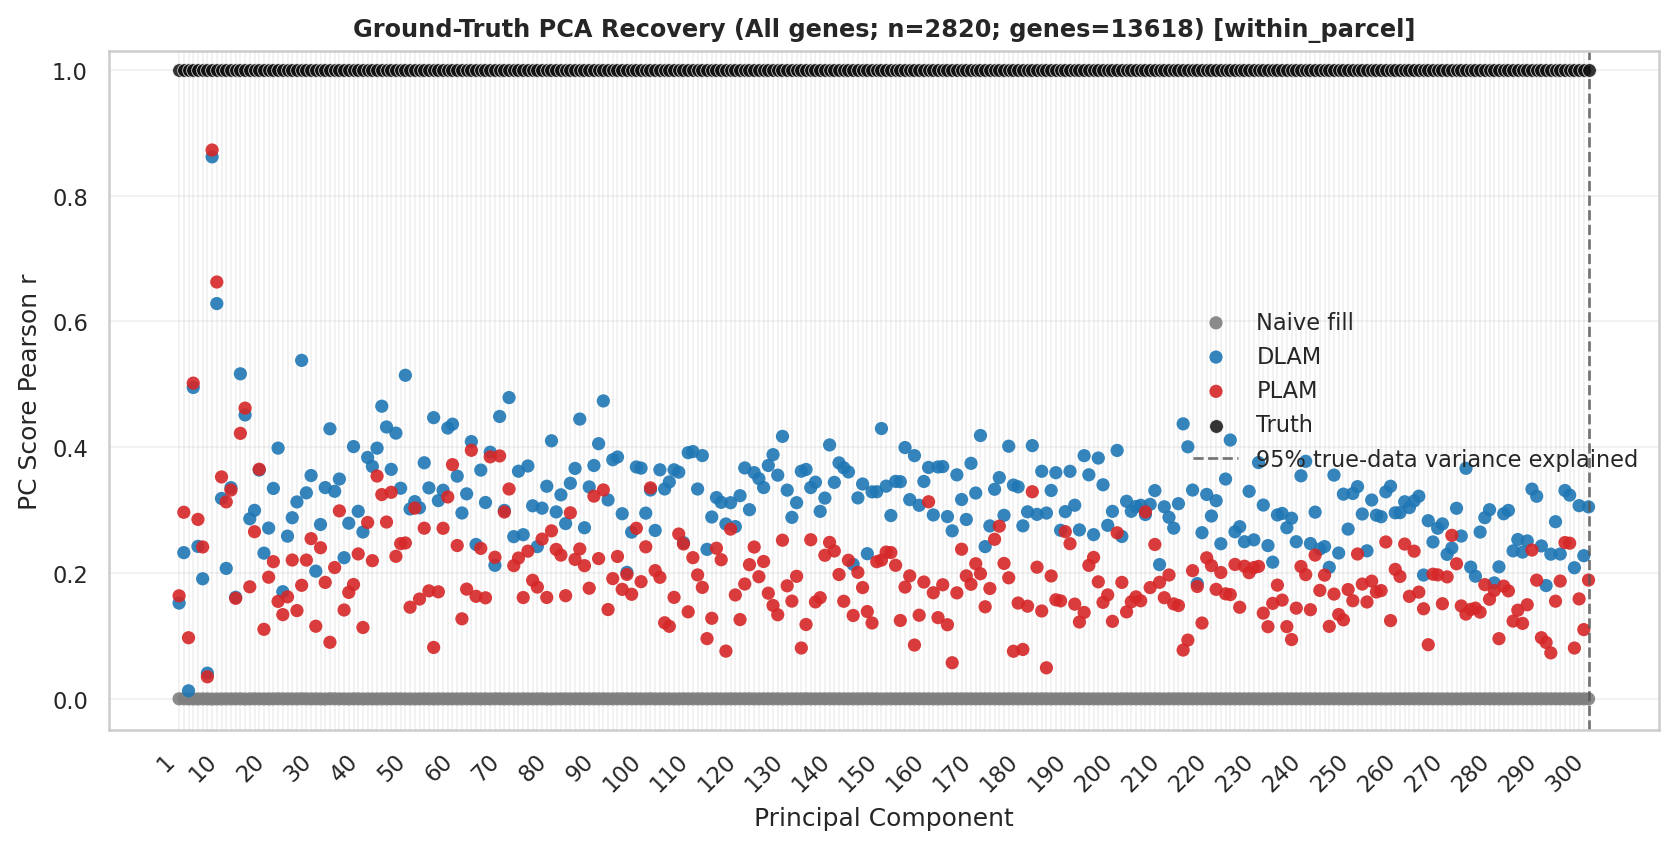

In [13]:
fig, ax, pc_plot_df_dm = plot_pooled_pca_recovery(
    pc_df_dm,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_lines=False,
    show_truth=True,
    x_label_stride=10,
)




### Within-Parcel PCA Recovery: LOWESS Smooth View

This view keeps the raw component-wise points but overlays a LOWESS smoother for each model so the overall recovery profile is easier to compare.

Because these are single component-wise scores rather than means over replicates, LOWESS is used here as a descriptive trend line rather than an inferential fit.




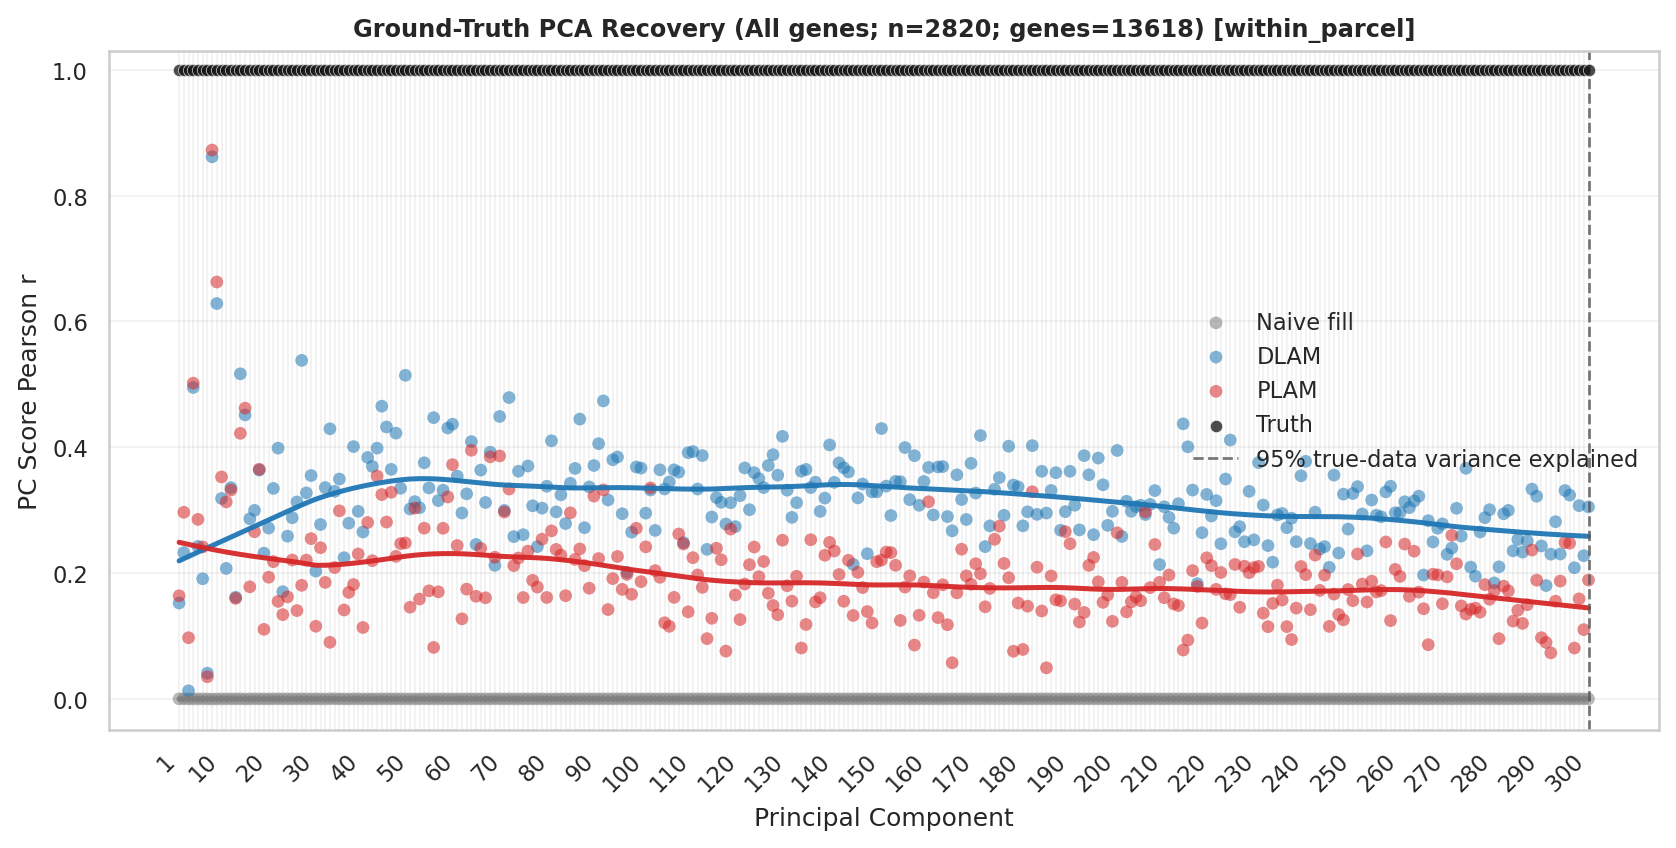

In [14]:
fig, ax, pc_plot_df_dm_fit = plot_pooled_pca_recovery(
    pc_df_dm,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_fit='lowess',
    lowess_frac=0.2,
    show_truth=True,
    x_label_stride=10,
)




## 5) Within-Parcel Variance Effects

This is a useful companion diagnostic.

Why:
- PCA recovery asks whether predicted variation aligns with the true latent axes
- within-parcel variance asks whether the model produces subject-to-subject variation at all

A model can have substantial within-parcel variance but still fail to align that variance with the dominant true PCA directions.

Here we evaluate the variance ranges for different tissues across models comparing to ground truth. 


In [15]:
# Compute mean std per parcel for each model, build DataFrame with models as rows and parcel_idx as columns
mean_std_by_model = {}

for name, df in {
    'truth': truth_df_naive,
    'naive': pred_df_naive,
    'dlam': pred_df_dlam,
    'plam': pred_df_plam,
}.items():
    # Compute mean sample std per gene, then average over genes for each parcel
    var_by_parcel = df.groupby('parcel_idx')[gene_cols].std().mean(axis=1)
    mean_std_by_model[name] = var_by_parcel

    print(f'\n{name}')
    display(var_by_parcel.describe())

# Compose into a DataFrame (models=rows, parcels=columns)
all_var_by_parcel_df = pd.DataFrame(mean_std_by_model).T
display(all_var_by_parcel_df.head())



truth


count    12.000000
mean      0.301164
std       0.033857
min       0.234322
25%       0.279534
50%       0.313824
75%       0.325411
max       0.338583
dtype: float64


naive


count    12.000000
mean      0.000387
std       0.000130
min       0.000274
25%       0.000311
50%       0.000329
75%       0.000421
max       0.000719
dtype: float64


dlam


count    12.000000
mean      0.556239
std       0.022225
min       0.509112
25%       0.545288
50%       0.556929
75%       0.575652
max       0.582755
dtype: float64


plam


count    12.000000
mean      0.411463
std       0.017603
min       0.384582
25%       0.405071
50%       0.408138
75%       0.420814
max       0.445883
dtype: float64

parcel_idx,0,5,10,16,18,19,29,31,38,55,94,132
truth,0.234322,0.274311,0.321191,0.338583,0.312306,0.323125,0.315343,0.254490,0.281275,0.335422,0.332269,0.291333
naive,0.000424,0.000555,0.000331,0.000307,0.000370,0.000322,0.000312,0.000287,0.000274,0.000326,0.000420,0.000719
dlam,0.564105,0.563474,0.540487,0.533832,0.581258,0.546888,0.509112,0.578821,0.549155,0.550384,0.582755,0.574596
plam,0.425287,0.407064,0.407924,0.419322,0.408352,0.416934,0.385615,0.429923,0.407581,0.399093,0.445883,0.384582


In [16]:
truth_df_naive.columns

Index(['subject', 'parcel_idx', 'sample_key', 'sample_idx_subject', 'model',
       'eval_gene_mode', 'eval_gene_path', 'mixed_space_mode', 'DPM1', 'SCYL3',
       ...
       'MRM1', 'HIST1H4A', 'GOLGA6L10', 'HIST1H2AM', 'HIST1H4B', 'HIST1H3H',
       'MRPL45', 'PCDH20', 'PAGR1', 'TMEM265'],
      dtype='object', length=13626)

In [17]:
truth_df_naive

,subject,parcel_idx,sample_key,sample_idx_subject,model,eval_gene_mode,eval_gene_path,mixed_space_mode,DPM1,SCYL3,...,MRM1,HIST1H4A,GOLGA6L10,HIST1H2AM,HIST1H4B,HIST1H3H,MRPL45,PCDH20,PAGR1,TMEM265
0,GTEX-1117F,5,GTEX-1117F|5,0,naive,all,None,None,5.237353,3.014178,...,2.943969,1.561887,3.505472,4.470888,4.863447,2.127437,5.699000,1.250517,6.218362,3.250597
1,GTEX-1117F,10,GTEX-1117F|10,1,naive,all,None,None,5.246482,3.045238,...,3.217235,1.506255,3.542502,4.555119,4.862676,1.319629,5.581843,3.912728,6.362165,3.091069
2,GTEX-1117F,18,GTEX-1117F|18,2,naive,all,None,None,5.184985,3.045365,...,3.291385,1.506969,3.492359,4.798620,4.864834,1.686910,5.499541,4.284439,6.362572,3.103423
3,GTEX-1117F,19,GTEX-1117F|19,3,naive,all,None,None,5.299481,3.069595,...,3.244307,1.506277,3.575236,4.810700,4.862178,1.487257,5.653855,3.580846,6.368560,3.076855
4,GTEX-1117F,29,GTEX-1117F|29,4,naive,all,None,None,5.407557,3.060759,...,2.908304,1.506248,3.545862,4.516249,4.863857,2.449167,5.933543,2.875592,6.387455,3.082352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2815,GTEX-ZVT3,18,GTEX-ZVT3|18,4,naive,all,None,None,5.509507,3.120522,...,2.783266,1.541884,3.523377,4.798568,4.864830,1.322528,6.249478,1.347782,6.430581,3.030046
2816,GTEX-ZVT3,19,GTEX-ZVT3|19,5,naive,all,None,None,5.636535,3.125278,...,2.603733,1.506272,3.570971,4.810648,4.862169,1.472074,6.459638,1.339286,6.475465,2.969153
2817,GTEX-ZVT3,31,GTEX-ZVT3|31,6,naive,all,None,None,5.169355,3.037594,...,3.352773,1.506835,3.306948,4.030719,4.863905,2.362468,5.542572,3.640587,6.353172,3.153359
2818,GTEX-ZVT3,38,GTEX-ZVT3|38,7,naive,all,None,None,5.258732,3.046531,...,3.122633,1.634546,3.430686,4.105021,4.493637,1.319561,5.717551,4.150727,6.396017,3.106852


In [18]:
import matplotlib.pyplot as plt
import numpy as np


def plot_sample_gene_heatmap(
    df,
    prepost=None,
    gene_list_path=None,
    sort_genes_by_mean=False,
    group_by=None,  # None | "subject" | "parcel"
    parcel_label_mode="gtex",  # gtex | ahba | both
    sample_n_genes=None,
    random_seed=0,
    figsize=None,
    cmap="viridis",
    title="Gene Expression Heatmap",
    row_scale=0.0015,
    font_size=13,
    line_color="white",
    line_width=0.8,
    right_label_pad=6,
):
    meta_cols = {
        "subject",
        "parcel_idx",
        "sample_key",
        "sample_idx_subject",
        "model",
        "eval_gene_mode",
        "eval_gene_path",
        "mixed_space_mode",
    }

    def _pretty_label(x):
        s = str(x)
        pref = "brain - "
        return s[len(pref):] if s.lower().startswith(pref) else s

    def _parcel_label_lookup(prepost_obj, mode="gtex"):
        if prepost_obj is None:
            return None

        target = prepost_obj["target_meta"][["parcel_idx", "tissue_or_parcel"]].copy()
        target["ahba_label"] = target["tissue_or_parcel"].astype(str)

        if mode == "ahba":
            return dict(zip(target["parcel_idx"].astype(int), target["ahba_label"]))

        g = prepost_obj["gtex_raw"].copy()
        native_map = (
            g.groupby("parcel_idx")["tissue_or_parcel"]
            .apply(lambda s: "; ".join(sorted(set(_pretty_label(str(x)) for x in s.dropna().tolist()))))
            .to_dict()
        )

        if mode == "gtex":
            return {
                int(row["parcel_idx"]): native_map.get(int(row["parcel_idx"]), row["ahba_label"])
                for _, row in target.iterrows()
            }

        if mode == "both":
            return {
                int(row["parcel_idx"]): f"{row['ahba_label']}: {native_map.get(int(row['parcel_idx']), row['ahba_label'])}"
                for _, row in target.iterrows()
            }

        raise ValueError("parcel_label_mode must be one of: 'gtex', 'ahba', 'both'")

    if gene_list_path is None:
        gene_cols = [c for c in df.columns if c not in meta_cols]
    else:
        with open(gene_list_path) as f:
            requested = [line.strip() for line in f if line.strip()]
        gene_cols = [g for g in requested if g in df.columns]

    if len(gene_cols) == 0:
        raise ValueError("No valid genes found to plot")

    if sample_n_genes is not None:
        sample_n_genes = int(sample_n_genes)
        if sample_n_genes < 1:
            raise ValueError("sample_n_genes must be >= 1")
        if sample_n_genes < len(gene_cols):
            rng = np.random.default_rng(int(random_seed))
            pick_idx = np.sort(rng.choice(len(gene_cols), size=sample_n_genes, replace=False))
            gene_cols = [gene_cols[i] for i in pick_idx]

    if sort_genes_by_mean:
        gene_means = df[gene_cols].mean(axis=0).sort_values(ascending=False)
        gene_cols = gene_means.index.tolist()

    plot_df = df.copy()
    boundary_positions = []
    right_tick_pos = []
    right_tick_labels = []

    if group_by is None:
        pass
    elif group_by == "subject":
        if "subject" not in plot_df.columns:
            raise ValueError("group_by='subject' requires a subject column")
        secondary = "parcel_idx" if "parcel_idx" in plot_df.columns else None
        sort_cols = ["subject"] + ([secondary] if secondary is not None else [])
        plot_df = plot_df.sort_values(sort_cols).reset_index(drop=True)
        group_sizes = plot_df.groupby("subject", sort=False).size().to_numpy()
        boundary_positions = np.cumsum(group_sizes)[:-1]
    elif group_by == "parcel":
        if "parcel_idx" not in plot_df.columns:
            raise ValueError("group_by='parcel' requires a parcel_idx column")
        secondary = "subject" if "subject" in plot_df.columns else None
        sort_cols = ["parcel_idx"] + ([secondary] if secondary is not None else [])
        plot_df = plot_df.sort_values(sort_cols).reset_index(drop=True)

        grp = plot_df.groupby("parcel_idx", sort=False)
        group_sizes = grp.size().to_numpy()
        boundary_positions = np.cumsum(group_sizes)[:-1]

        starts = np.r_[0, np.cumsum(group_sizes)[:-1]]
        ends = np.cumsum(group_sizes)
        right_tick_pos = ((starts + ends - 1) / 2.0).tolist()

        lookup = _parcel_label_lookup(prepost, mode=parcel_label_mode)
        parcel_ids = grp.size().index.tolist()
        if lookup is None:
            right_tick_labels = [f"parcel {int(p)}" for p in parcel_ids]
        else:
            right_tick_labels = [lookup.get(int(p), f"parcel {int(p)}") for p in parcel_ids]
    else:
        raise ValueError("group_by must be one of: None, 'subject', 'parcel'")

    data = plot_df[gene_cols].to_numpy(dtype=float)

    if figsize is None:
        extra_w = 6.0 if group_by == "parcel" else 0.0
        figsize = (
            min(22, max(8 + extra_w, 0.09 * len(gene_cols) + extra_w)),
            min(6, max(2.5, row_scale * data.shape[0] + 1.2)),
        )

    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })

    fig, ax = plt.subplots(figsize=figsize)

    if group_by == "parcel" and len(right_tick_pos) > 0:
        fig.subplots_adjust(right=0.72)
    else:
        fig.subplots_adjust(right=0.88)

    im = ax.imshow(
        data,
        aspect="auto",
        cmap=cmap,
        interpolation="none",
    )

    ax.set_xlabel("Gene")
    ax.set_ylabel("Sample")
    ttl = title if group_by is None else f"{title} ({group_by}-grouped)"
    if sample_n_genes is not None:
        ttl += f" [random {len(gene_cols)} genes; seed={int(random_seed)}]"
    ax.set_title(ttl)

    for y in boundary_positions:
        ax.axhline(y - 0.5, color=line_color, linewidth=line_width, alpha=0.9)

    ax.grid(False)
    ax.xaxis.grid(False, which="both")
    ax.yaxis.grid(False, which="both")
    ax.minorticks_off()

    if group_by == "parcel" and len(right_tick_pos) > 0:
        ax_r = ax.twinx()
        ax_r.set_ylim(ax.get_ylim())
        ax_r.set_yticks(right_tick_pos)
        ax_r.set_yticklabels(right_tick_labels, fontsize=font_size - 1, va="center")
        ax_r.set_ylabel("Parcel", fontsize=font_size)
        ax_r.tick_params(axis="y", length=0, pad=right_label_pad)
        ax_r.grid(False)
        for spine in ax_r.spines.values():
            spine.set_visible(False)

        cax = fig.add_axes([0.94, 0.14, 0.018, 0.72])
        cbar = fig.colorbar(im, cax=cax)
    else:
        cbar = fig.colorbar(im, ax=ax, pad=0.03)

    cbar.set_label("Expression", fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size - 1)

    return fig, ax, gene_cols


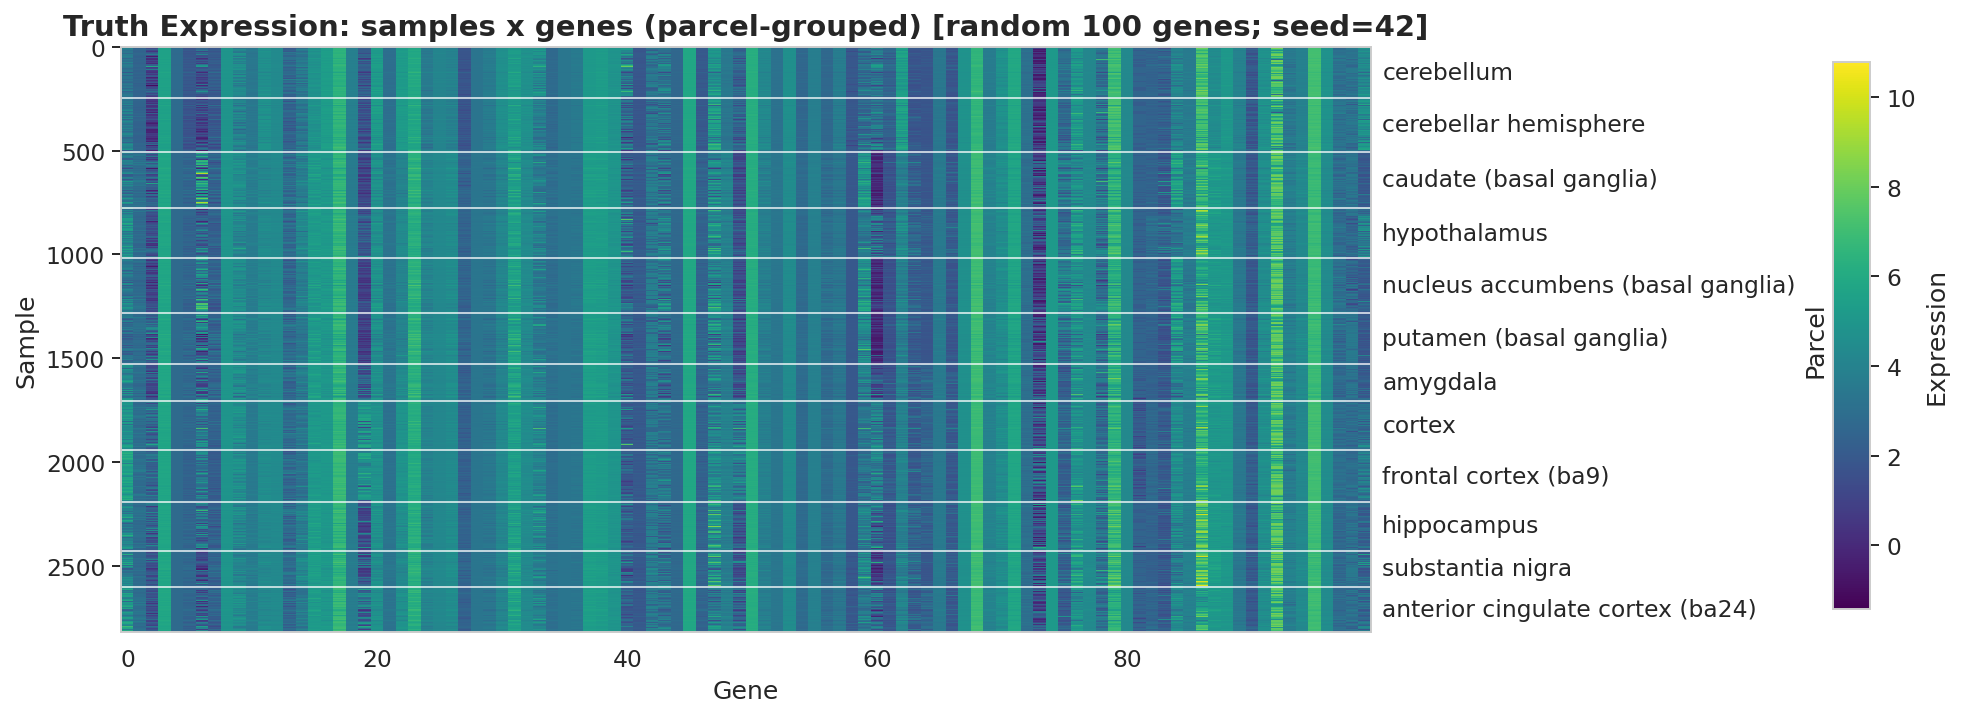

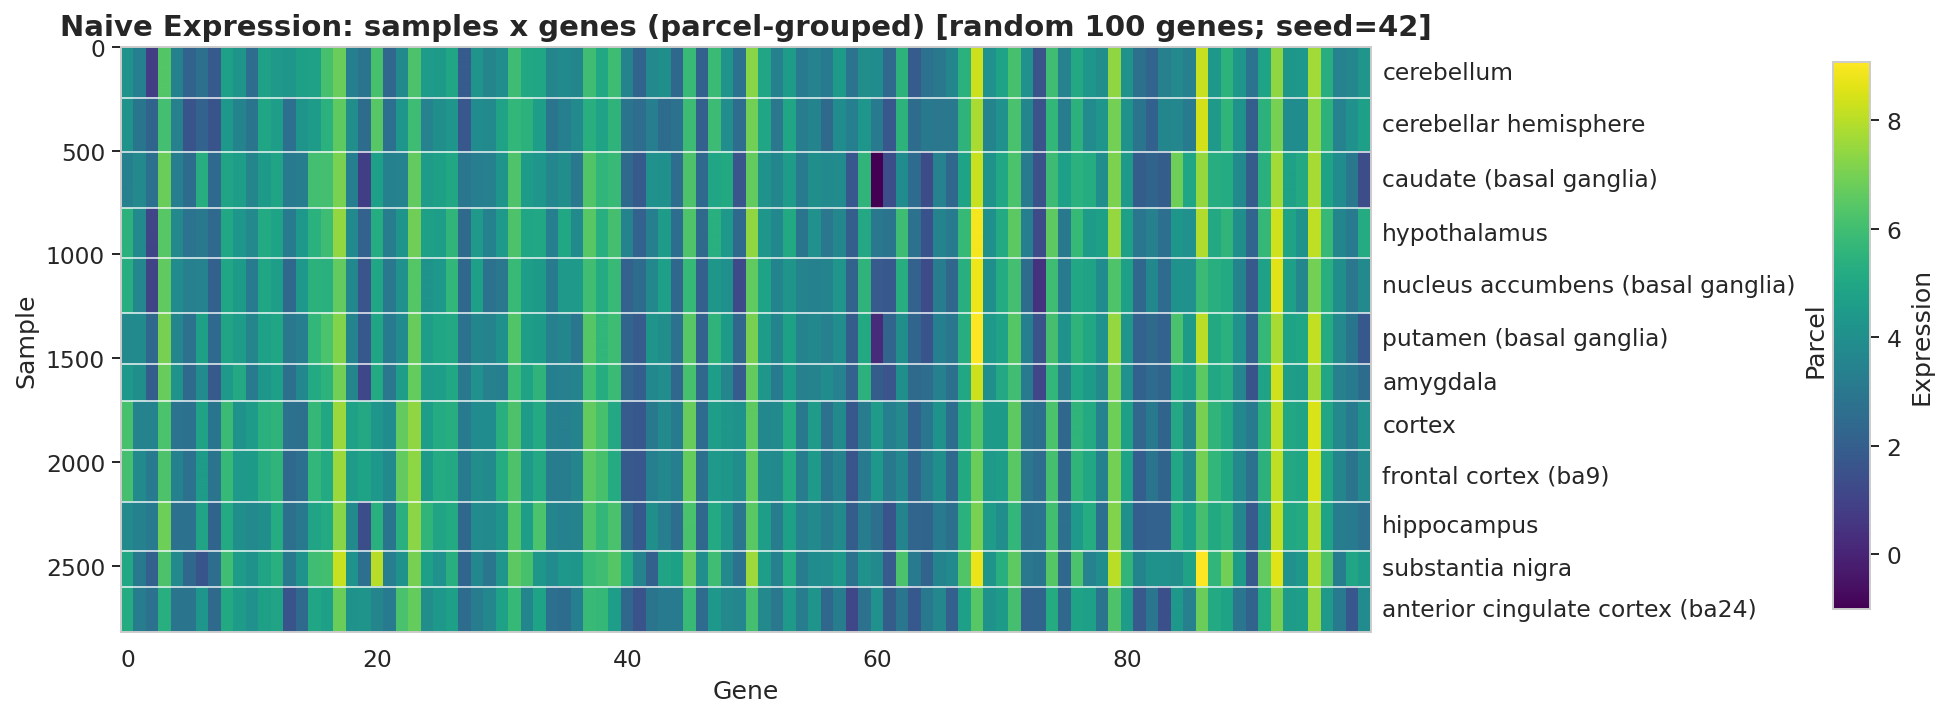

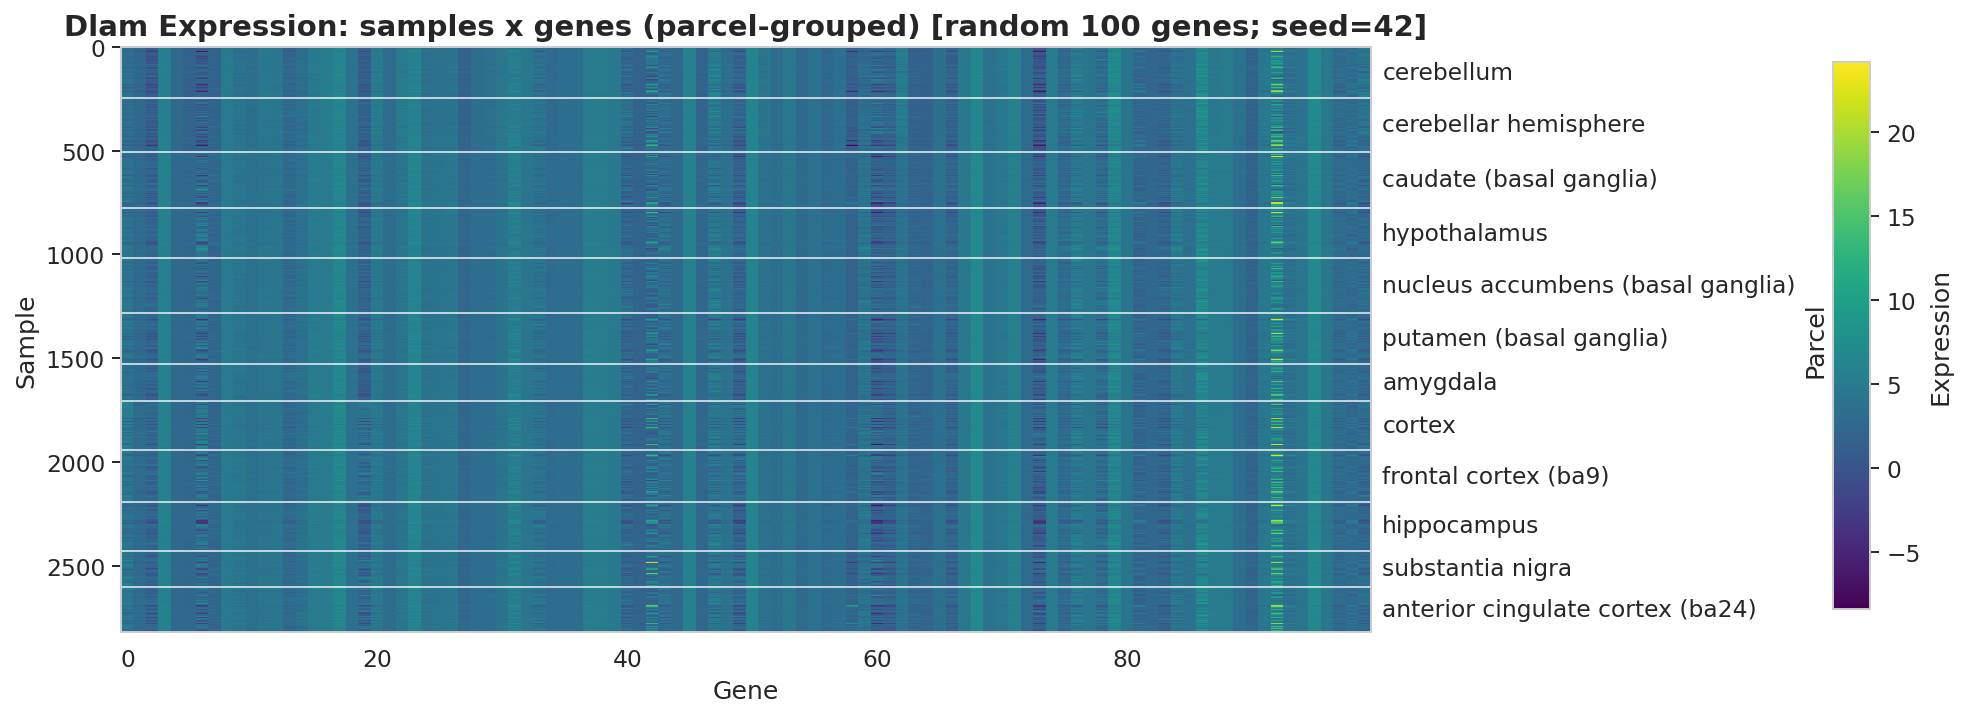

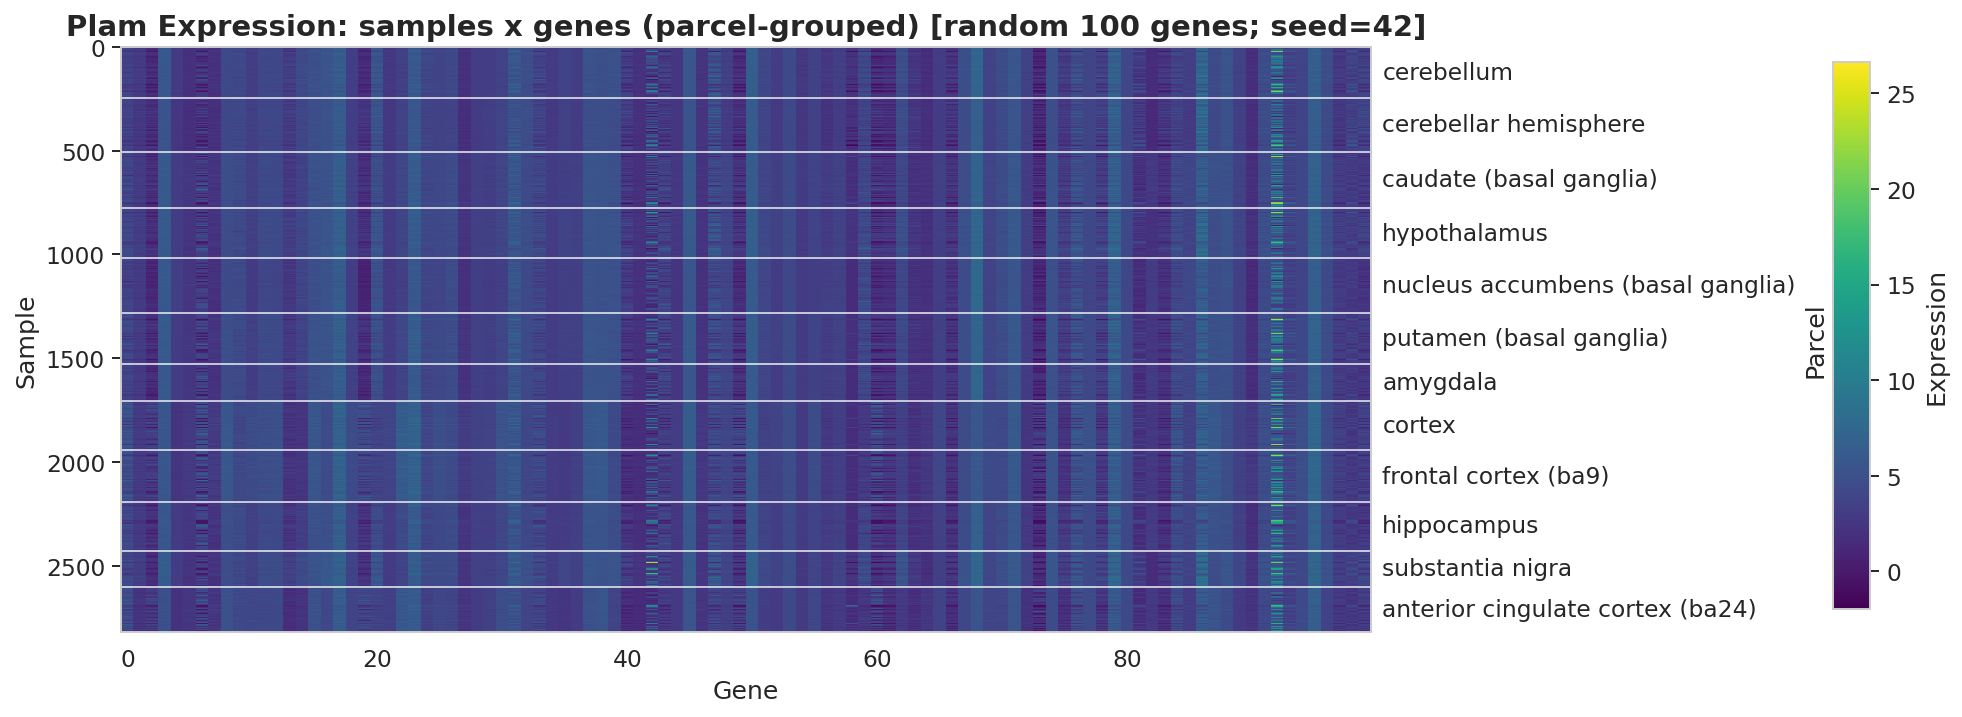

In [19]:
HEATMAP_MODELS = {
    "truth": truth_df_naive,
    "naive": pred_df_naive,
    "dlam": pred_df_dlam,
    "plam": pred_df_plam,
}

for model_name, df_plot in HEATMAP_MODELS.items():
    fig, ax, gene_order = plot_sample_gene_heatmap(
        df_plot,
        prepost=PREPOST,
        gene_list_path=None, 
        sort_genes_by_mean=False,
        group_by="parcel",
        parcel_label_mode="gtex",
        sample_n_genes=100,
        random_seed=42,
        title=f"{model_name.capitalize()} Expression: samples x genes",
    )


## Scatters

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D


def plot_parcel_prediction_variance_scatter_triplet(
    truth_df,
    pred_df_naive,
    pred_df_dlam,
    pred_df_plam,
    prepost,
    parcel,
    gene_list_path=None,
    n_genes=None,
    random_seed=0,
    color_by="none",  # none | gene
    top_n_gene_colors=12,
    figsize=(17.2, 5.8),
    point_size=14.0,
    alpha=0.45,
    subtitle_pad=16,
    suptitle_y=1.08,
):
    meta_cols = {
        "subject",
        "parcel_idx",
        "sample_key",
        "sample_idx_subject",
        "model",
        "eval_gene_mode",
        "eval_gene_path",
        "mixed_space_mode",
    }

    def _pretty_label(x):
        s = str(x)
        pref = "brain - "
        return s[len(pref):] if s.lower().startswith(pref) else s

    def _pearson_safe(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 2:
            return np.nan
        x = x[m]
        y = y[m]
        if np.std(x) == 0 or np.std(y) == 0:
            return np.nan
        return float(np.corrcoef(x, y)[0, 1])

    def _spearman_safe(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 2:
            return np.nan
        x = x[m]
        y = y[m]
        xr = np.argsort(np.argsort(x))
        yr = np.argsort(np.argsort(y))
        if np.std(xr) == 0 or np.std(yr) == 0:
            return np.nan
        return float(np.corrcoef(xr, yr)[0, 1])

    def _rmse_safe(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() == 0:
            return np.nan
        return float(np.sqrt(np.mean((x[m] - y[m]) ** 2)))

    def _build_parcel_label_table(prepost_obj):
        target = prepost_obj["target_meta"][["parcel_idx", "tissue_or_parcel"]].copy()
        target["ahba_label"] = target["tissue_or_parcel"].astype(str)

        g = prepost_obj["gtex_raw"].copy()
        native_map = (
            g.groupby("parcel_idx")["tissue_or_parcel"]
            .apply(lambda s: "; ".join(sorted(set(_pretty_label(str(x)) for x in s.dropna().tolist()))))
            .to_dict()
        )

        out = target.copy()
        out["gtex_label"] = out["parcel_idx"].map(native_map).fillna("")
        out["label"] = np.where(
            out["gtex_label"].astype(str).str.len() > 0,
            out["gtex_label"],
            out["ahba_label"],
        )
        return out

    def _resolve_parcel(parcel_value, prepost_obj):
        table = _build_parcel_label_table(prepost_obj)

        if isinstance(parcel_value, int):
            return int(parcel_value)

        s = str(parcel_value).strip()
        if s.isdigit():
            return int(s)

        s_low = s.lower()

        exact = table[table["label"].astype(str).str.lower() == s_low]
        if len(exact) > 0:
            return int(exact.iloc[0]["parcel_idx"])

        exact2 = table[table["ahba_label"].astype(str).str.lower() == s_low]
        if len(exact2) > 0:
            return int(exact2.iloc[0]["parcel_idx"])

        partial = table[
            table["label"].astype(str).str.lower().str.contains(s_low, regex=False)
            | table["ahba_label"].astype(str).str.lower().str.contains(s_low, regex=False)
        ]
        if len(partial) == 1:
            return int(partial.iloc[0]["parcel_idx"])
        if len(partial) > 1:
            matches = partial[["parcel_idx", "label"]].to_dict("records")
            raise ValueError(f"Parcel name matched multiple entries: {matches}")

        raise ValueError(f"Could not resolve parcel {parcel_value!r}")

    def _parcel_display_label(parcel_idx, prepost_obj):
        table = _build_parcel_label_table(prepost_obj)
        row = table[table["parcel_idx"].astype(int) == int(parcel_idx)]
        if len(row) == 0:
            return f"parcel {int(parcel_idx)}"
        return str(row.iloc[0]["label"])

    def _resolve_gene_cols(df, gene_list_path_value, n_genes_value, seed_value):
        if gene_list_path_value is None:
            genes = [c for c in df.columns if c not in meta_cols]
        else:
            with open(gene_list_path_value) as f:
                requested = [line.strip() for line in f if line.strip()]
            genes = [g for g in requested if g in df.columns]

        if len(genes) == 0:
            raise ValueError("No valid genes found")

        if n_genes_value is not None:
            n_use = int(n_genes_value)
            if n_use < 1:
                raise ValueError("n_genes must be >= 1")
            if n_use < len(genes):
                rng = np.random.default_rng(int(seed_value))
                keep = np.sort(rng.choice(len(genes), size=n_use, replace=False))
                genes = [genes[i] for i in keep]

        return genes

    def _scatter_by_gene(ax, x, y, gene_ids, gene_names, model_color):
        mode = str(color_by).lower()
        if mode == "none":
            ax.scatter(x, y, s=point_size, alpha=alpha, color=model_color, linewidths=0, marker="o")
            return []

        if mode != "gene":
            raise ValueError("color_by must be one of: none, gene")

        uniq, counts = np.unique(gene_ids, return_counts=True)
        order = uniq[np.argsort(-counts)]
        keep = order[: int(top_n_gene_colors)]
        base = ~np.isin(gene_ids, keep)

        ax.scatter(
            x[base],
            y[base],
            s=max(4.0, point_size - 4.0),
            alpha=max(0.12, alpha * 0.28),
            color="#b5b5b5",
            linewidths=0,
            marker="o",
        )

        palette = sns.color_palette("tab10", n_colors=max(1, len(keep)))
        handles = []
        for c, gid in zip(palette, keep):
            m = gene_ids == gid
            ax.scatter(
                x[m],
                y[m],
                s=point_size,
                alpha=alpha,
                color=c,
                linewidths=0,
                marker="o",
            )
            handles.append(
                Line2D(
                    [0], [0],
                    marker="o",
                    color="none",
                    markerfacecolor=c,
                    markersize=6,
                    label=str(gene_names[int(gid)]),
                )
            )
        return handles

    parcel_idx = _resolve_parcel(parcel, prepost)
    parcel_label = _parcel_display_label(parcel_idx, prepost)
    gene_cols = _resolve_gene_cols(truth_df, gene_list_path, n_genes, random_seed)

    model_frames = {
        "naive": pred_df_naive,
        "dlam": pred_df_dlam,
        "plam": pred_df_plam,
    }
    model_colors = {
        "naive": "#7f7f7f",
        "dlam": "#1f77b4",
        "plam": "#d62728",
    }
    model_labels = {
        "naive": "Naive fill",
        "dlam": "DLAM",
        "plam": "PLAM",
    }

    truth_sub = (
        truth_df[truth_df["parcel_idx"].astype(int) == int(parcel_idx)]
        .sort_values("subject")
        .reset_index(drop=True)
    )
    if len(truth_sub) == 0:
        raise ValueError(f"No rows found for parcel_idx={parcel_idx}")

    panel_data = {}
    all_vals = []

    for model_name, pred_df in model_frames.items():
        pred_sub = (
            pred_df[pred_df["parcel_idx"].astype(int) == int(parcel_idx)]
            .sort_values("subject")
            .reset_index(drop=True)
        )

        merged = truth_sub[["subject"] + gene_cols].merge(
            pred_sub[["subject"] + gene_cols],
            on="subject",
            suffixes=("_true", "_pred"),
            how="inner",
        )
        if len(merged) == 0:
            raise ValueError(f"No aligned subject rows for model={model_name} at parcel_idx={parcel_idx}")

        x_mat = merged[[f"{g}_true" for g in gene_cols]].to_numpy(dtype=float)
        y_mat = merged[[f"{g}_pred" for g in gene_cols]].to_numpy(dtype=float)

        x = x_mat.ravel()
        y = y_mat.ravel()
        gene_ids = np.tile(np.arange(len(gene_cols), dtype=np.int32), x_mat.shape[0])

        m = np.isfinite(x) & np.isfinite(y)
        x = x[m]
        y = y[m]
        gene_ids = gene_ids[m]

        panel_data[model_name] = {
            "x": x,
            "y": y,
            "gene_ids": gene_ids,
            "pearson": _pearson_safe(x, y),
            "spearman": _spearman_safe(x, y),
            "rmse": _rmse_safe(x, y),
            "n": int(len(x)),
            "n_subjects": int(len(merged)),
        }
        all_vals.append(x)
        all_vals.append(y)

    vals = np.concatenate(all_vals) if len(all_vals) else np.array([0.0, 1.0])
    lim_lo = float(np.nanpercentile(vals, 0.5))
    lim_hi = float(np.nanpercentile(vals, 99.5))
    if not np.isfinite(lim_lo) or not np.isfinite(lim_hi) or lim_hi <= lim_lo:
        lim_lo, lim_hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    if not np.isfinite(lim_lo) or not np.isfinite(lim_hi) or lim_hi <= lim_lo:
        lim_lo, lim_hi = 0.0, 1.0
    pad = 0.04 * (lim_hi - lim_lo if lim_hi > lim_lo else 1.0)
    lim_lo -= pad
    lim_hi += pad

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)
    fig.subplots_adjust(right=0.80, top=0.80, wspace=0.28)

    global_gene_handles = None

    for ax, model_name in zip(axes, ["naive", "dlam", "plam"]):
        x = panel_data[model_name]["x"]
        y = panel_data[model_name]["y"]
        gene_ids = panel_data[model_name]["gene_ids"]

        gene_handles = _scatter_by_gene(ax, x, y, gene_ids, gene_cols, model_colors[model_name])
        if global_gene_handles is None and gene_handles:
            global_gene_handles = gene_handles

        ax.plot(
            [lim_lo, lim_hi],
            [lim_lo, lim_hi],
            linestyle="--",
            linewidth=1.2,
            color="#5f5f5f",
            alpha=0.85,
            zorder=0,
        )

        ax.set_title(
            f"{model_labels[model_name]} vs Truth",
            fontsize=13,
            fontweight="bold",
            pad=subtitle_pad,
        )
        ax.set_xlim(lim_lo, lim_hi)
        ax.set_ylim(lim_lo, lim_hi)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.20)

        base_handles = [
            Line2D([0], [0], linestyle="--", color="#5f5f5f", linewidth=1.2, label="Identity"),
        ]
        if str(color_by).lower() == "none":
            base_handles.insert(
                0,
                Line2D([0], [0], marker="o", color="none", markerfacecolor=model_colors[model_name], markersize=6, label="Predicted"),
            )
        else:
            base_handles.insert(
                0,
                Line2D([0], [0], marker="o", color="none", markerfacecolor="#b5b5b5", markersize=6, label="Other genes"),
            )

        leg1 = ax.legend(
            handles=base_handles,
            loc="upper left",
            frameon=True,
            fontsize=9,
        )
        ax.add_artist(leg1)

        color_desc = "none" if str(color_by).lower() == "none" else f"gene (top {int(top_n_gene_colors)})"
        ax.text(
            0.985,
            0.03,
            (
                f"r={panel_data[model_name]['pearson']:.3f}\n"
                f"rho={panel_data[model_name]['spearman']:.3f}\n"
                f"rmse={panel_data[model_name]['rmse']:.3f}\n"
                f"n={panel_data[model_name]['n']:,}\n"
                f"subjects={panel_data[model_name]['n_subjects']}\n"
                f"genes={len(gene_cols)}\n"
                f"colored by: {color_desc}"
            ),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            bbox={"facecolor": "white", "edgecolor": "#808080", "alpha": 0.92, "boxstyle": "round,pad=0.25"},
        )

    axes[0].set_ylabel("Predicted expression", fontsize=11)
    for ax in axes:
        ax.set_xlabel("True expression", fontsize=11)

    gene_label = "All genes" if gene_list_path is None else gene_list_path.split("/")[-1].replace(".txt", "")
    sample_note = f"; random {len(gene_cols)} genes; seed={int(random_seed)}" if n_genes is not None else ""
    fig.suptitle(
        f"Parcel Prediction Scatter: {parcel_label} (parcel_idx={parcel_idx}; {gene_label}{sample_note})",
        fontsize=14,
        fontweight="bold",
        y=suptitle_y,
    )

    if global_gene_handles:
        fig.legend(
            handles=global_gene_handles,
            loc="center left",
            bbox_to_anchor=(0.83, 0.5),
            frameon=True,
            fontsize=8,
            title=f"Genes (top {min(top_n_gene_colors, len(global_gene_handles))})",
            title_fontsize=9,
        )

    out = {
        "parcel_idx": int(parcel_idx),
        "parcel_label": parcel_label,
        "gene_cols": gene_cols,
        "panel_data": panel_data,
    }
    return fig, axes, out


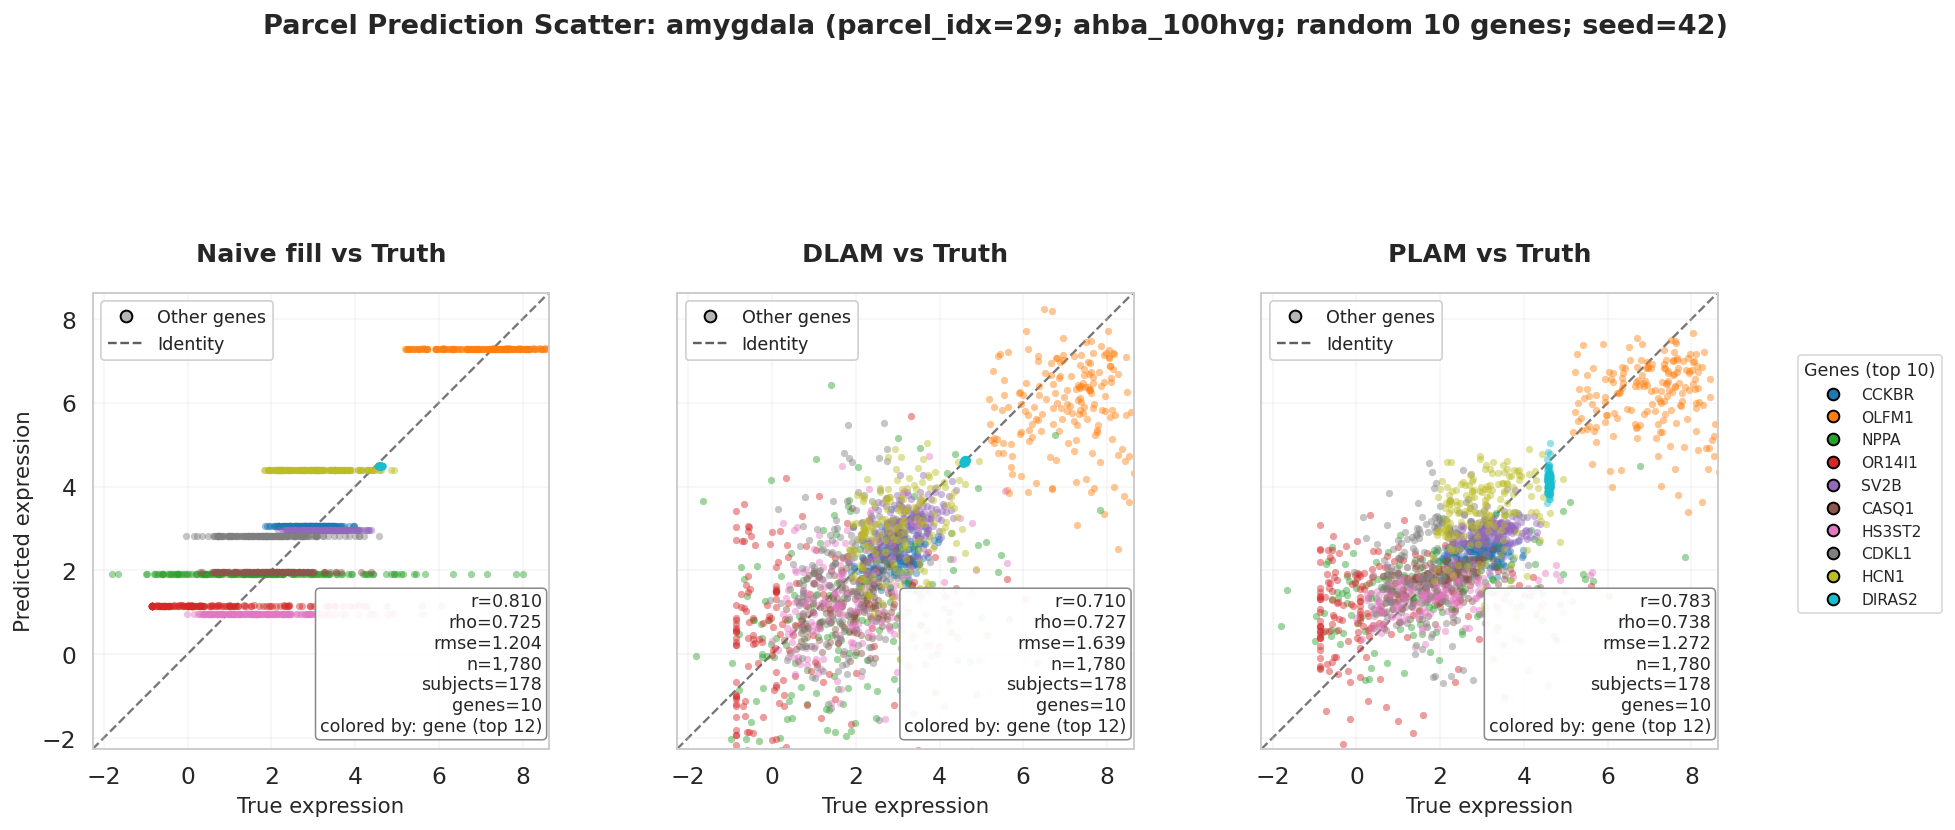

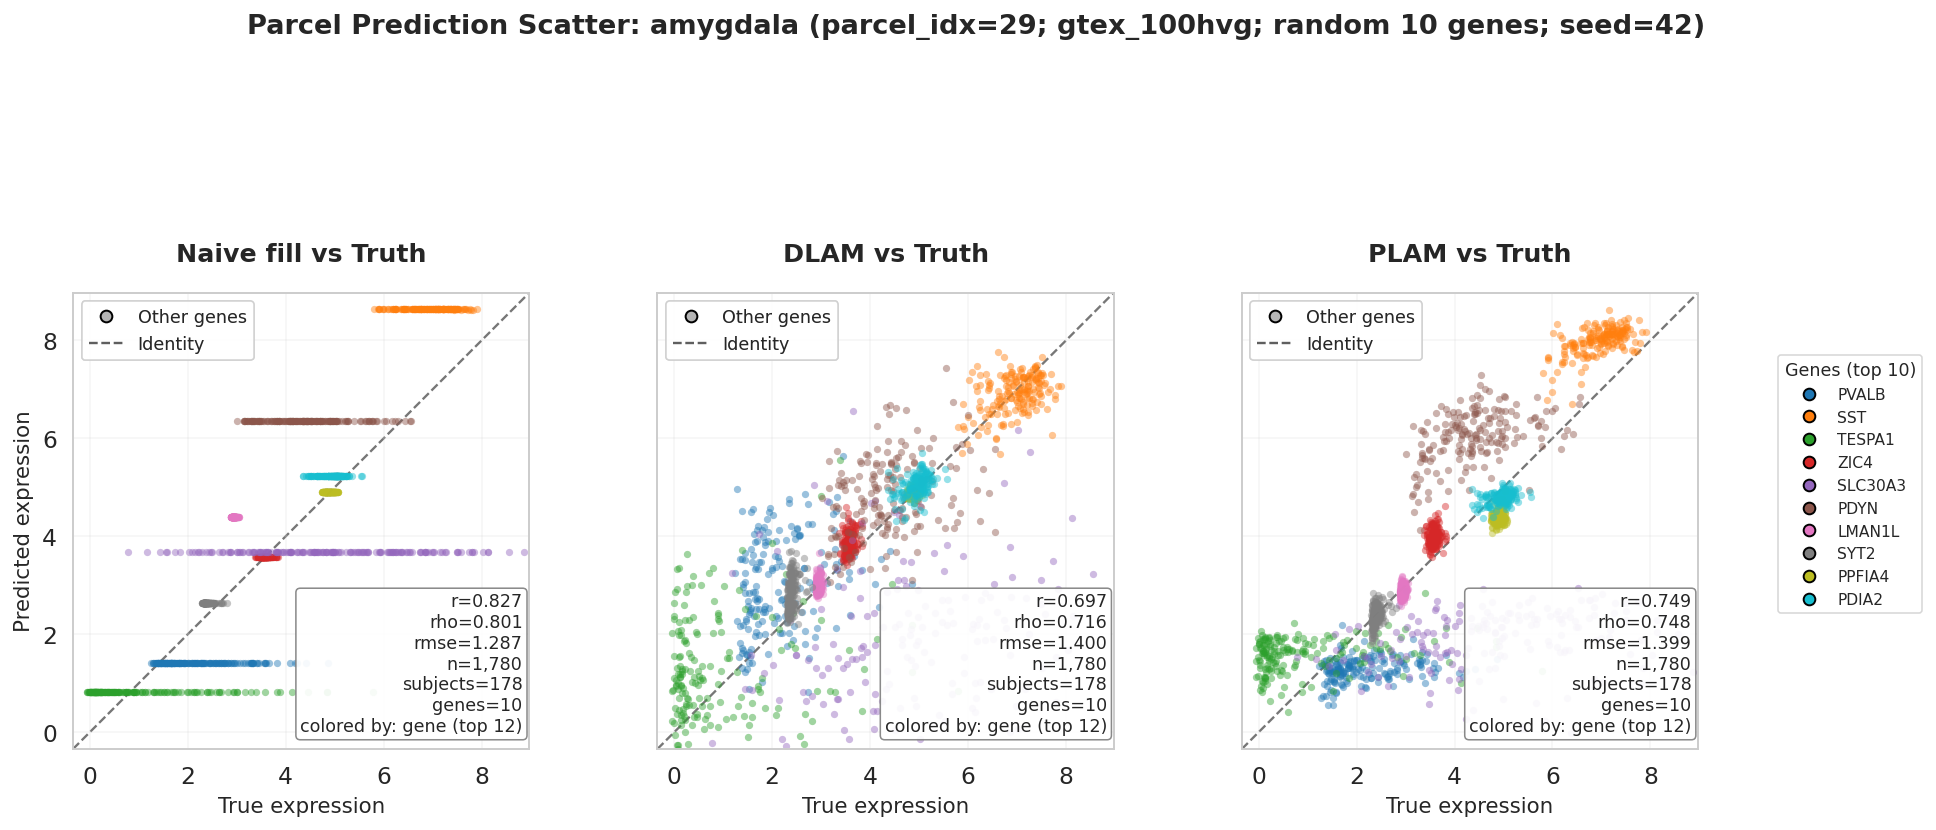

In [21]:
parcel="amygdala"

fig, axes, out = plot_parcel_prediction_variance_scatter_triplet(
    truth_df=truth_df_naive,
    pred_df_naive=pred_df_naive,
    pred_df_dlam=pred_df_dlam,
    pred_df_plam=pred_df_plam,
    prepost=PREPOST,
    parcel=parcel,
    gene_list_path='data/raw/gene_lists/ahba_100hvg.txt',
    color_by="gene",
    n_genes=10,
    random_seed=42
)

fig, axes, out = plot_parcel_prediction_variance_scatter_triplet(
    truth_df=truth_df_naive,
    pred_df_naive=pred_df_naive,
    pred_df_dlam=pred_df_dlam,
    pred_df_plam=pred_df_plam,
    prepost=PREPOST,
    parcel=parcel,
    gene_list_path='data/raw/gene_lists/gtex_100hvg.txt',
    color_by="gene",
    n_genes=10,
    random_seed=42
)



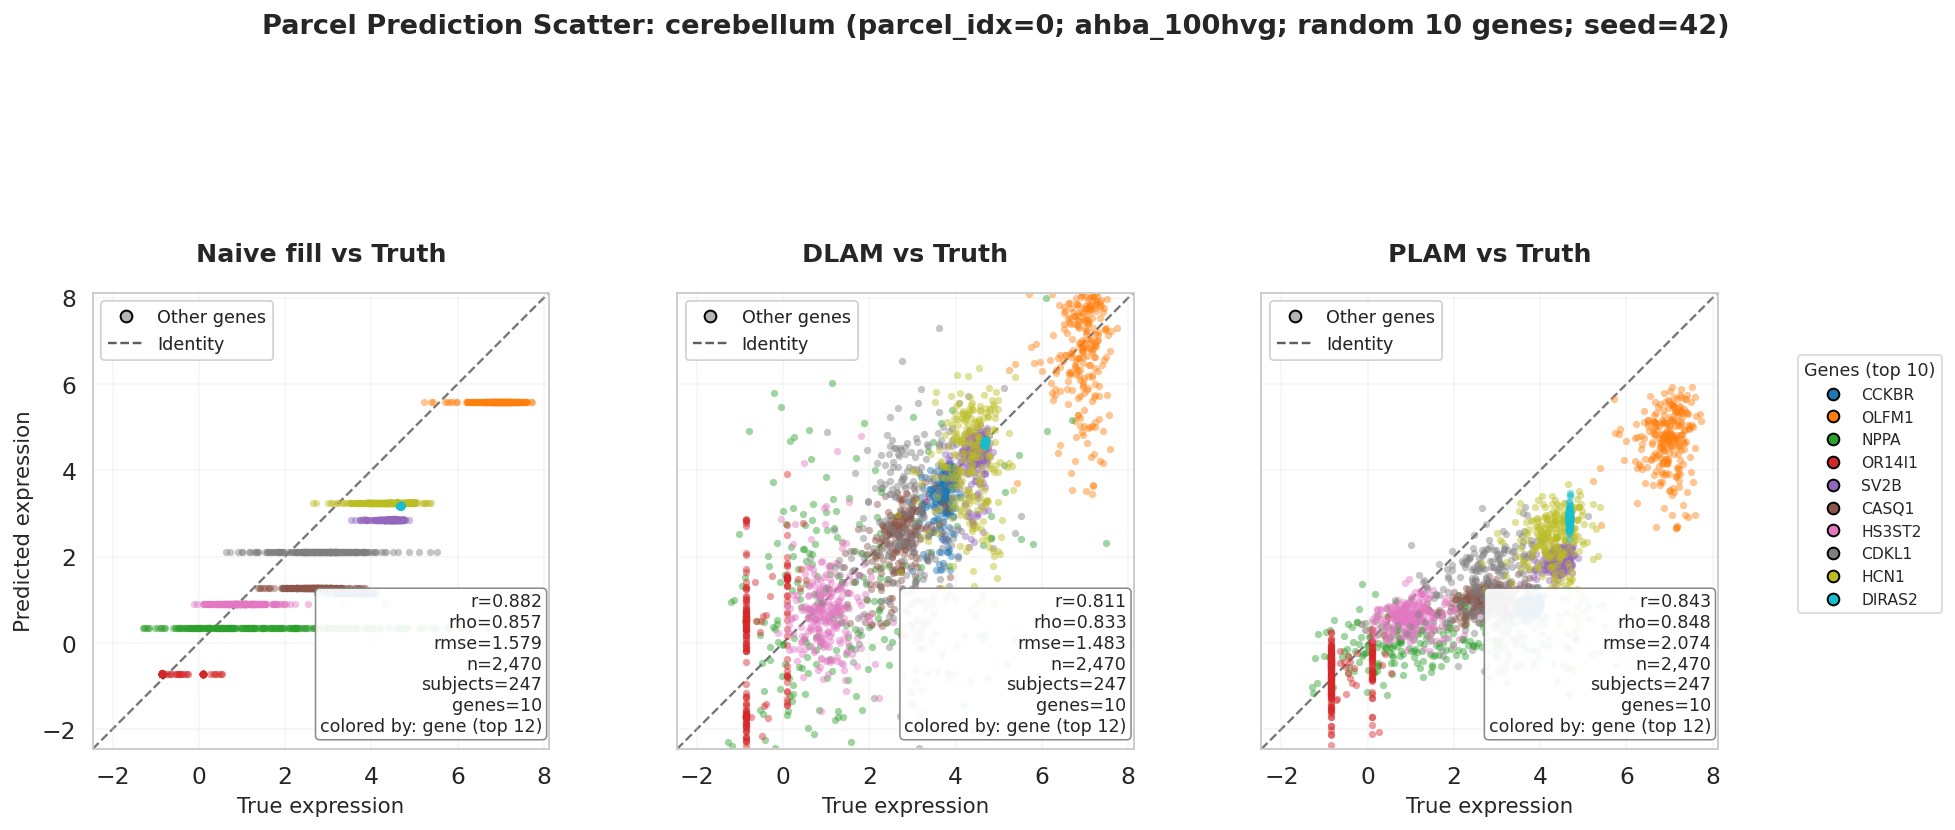

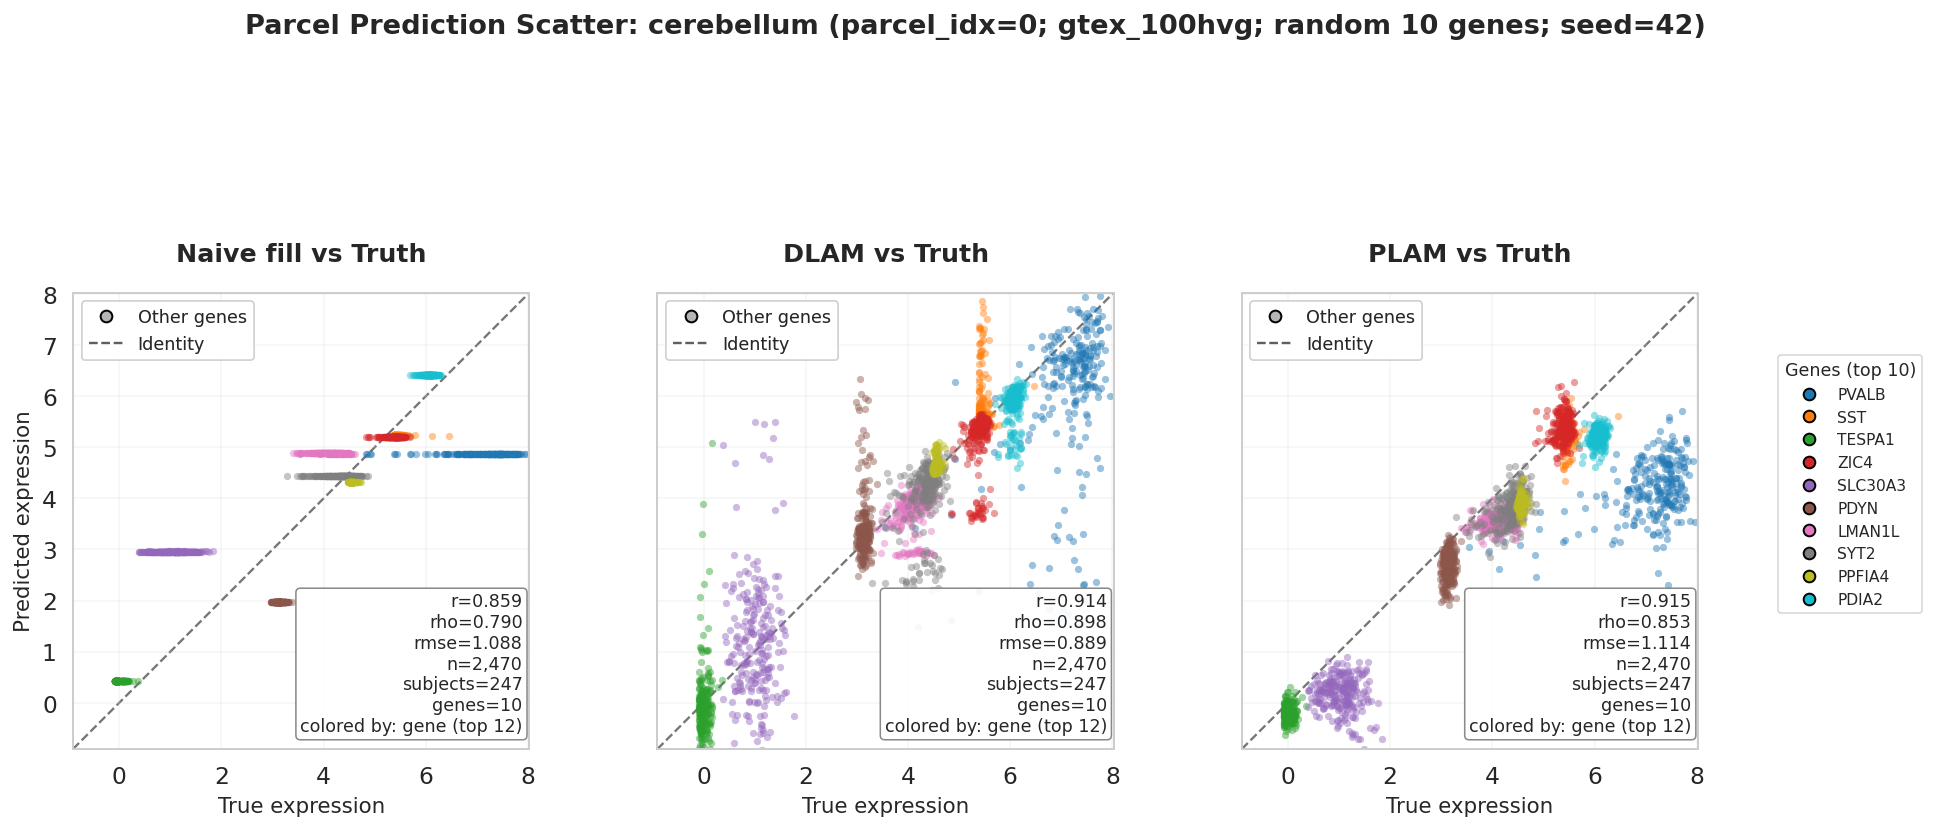

In [22]:
parcel="cerebellum"

fig, axes, out = plot_parcel_prediction_variance_scatter_triplet(
    truth_df=truth_df_naive,
    pred_df_naive=pred_df_naive,
    pred_df_dlam=pred_df_dlam,
    pred_df_plam=pred_df_plam,
    prepost=PREPOST,
    parcel=parcel,
    gene_list_path='data/raw/gene_lists/ahba_100hvg.txt',
    color_by="gene",
    n_genes=10,
    random_seed=42
)

fig, axes, out = plot_parcel_prediction_variance_scatter_triplet(
    truth_df=truth_df_naive,
    pred_df_naive=pred_df_naive,
    pred_df_dlam=pred_df_dlam,
    pred_df_plam=pred_df_plam,
    prepost=PREPOST,
    parcel=parcel,
    gene_list_path='data/raw/gene_lists/gtex_100hvg.txt',
    color_by="gene",
    n_genes=10,
    random_seed=42
)

